# TimeGAN A12 v15 — Generator Pre-Training + Iman-Conover Correlation Remapping
## Dataset: SWaT A12 — Marzo 2026

---

## Historial de versiones A12

| Version | EmbMSE | SupLoss | D final | Spikes | dm_preQM | D3 latent | D5 corr_diff |
|---------|--------|---------|---------|--------|----------|-----------|-------------|
| v12 | 0.000561 | 0.004173 | 1.8522 | 851 | 0.0346 | separado | N/A |
| v13 | 0.000242 | 0.002707 | 1.5844 | 0 | 0.1307 | separado | N/A |
| v14 | 0.000150 | 0.003533 | 1.7659 | 130 | 0.0122 | separado | 0.2351 |
| **v15** | TBD | TBD | TBD | TBD | TBD | **?** | **?** |
| A7 v21 | 0.000121 | 0.002200 | 2.0751 | 104 | 0.0048 | solapado | N/A |

## Diagnosticos de v14 y sus fixes en v15

### D1 (Embedder) - RESUELTO en v14
MSE=0.000150 (A7: 0.000121). Todos los sensores RMSE < 0.022. No requiere cambios.

### D2 (Supervisor) - ACEPTABLE
Ratio free-run/tf=5.82x. Loss=0.003533 > A7(0.002200). Con mejor G (fix D3), puede mejorar.

### D3 (Generador) - FIX: Generator Pre-Training

**Problema:** el t-SNE latente mostraba h_synth como un blob compacto totalmente separado
de h_real. El generador aprende una distribucion latente INCORRECTA.

**Causa:** G inicia desde pesos aleatorios, produciendo h muy diferentes a h_real.
El entrenamiento adversarial deberia corregir esto, pero el discriminador explota
periodicamente (D=26.4 en ep1100) antes de que G encuentre el manifold real.

**Fix: Generator Pre-Training (300 epocas)**
Antes del joint training, se pre-entrena G para minimizar MSE(G(z), h_real).
Esto coloca a G cerca del manifold real ANTES de que empiece la competencia adversarial.
Cuando empieza el joint training, D y G parten de una posicion balanceada.

```
Sin pre-training: G(z) -> h en region aleatoria -> D distingue facilmente -> G colapsado
Con pre-training: G(z) -> h cerca de h_real -> D trabaja mas -> equilibrio mas estable
```

### D4 (Pre-QM) - MEJORADO en v14
diff_medias=0.0122 (v13: 0.1307). ratio_intra max ~6x. Persisten algunos sensores con drift.

### D5 (Correlaciones) - FIX: Iman-Conover Remapping

**Problema:** diferencia media de correlaciones = 0.2351 (ideal < 0.10).
LIT101 vs AIT301: real=-0.302, sint=+0.653 (INVERTIDA).
Las relaciones fisicas del sistema SWaT no se capturan correctamente.

**Fix: Iman-Conover Rank Correlation Matching**
Metodo matematico que preserva las marginales exactamente mientras impone
la estructura de correlacion cruzada de los datos reales.

Funciona a nivel de ventanas: para cada sensor j, rearregla CUALES ventanas
se asignan a cada posicion para que la correlacion conjunta entre sensores
coincida con la correlacion real. La forma temporal DENTRO de cada ventana
se preserva completamente (no se mezclan timesteps).

### D6 (Autocorrelacion) - OK en v14
ACF1 diff media < 0.006. Estructura temporal correcta. No requiere cambios.


## 0. Imports e inicialización

In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1. Rutas del proyecto

Todos los artefactos de este notebook se guardan en `models/timegan/conv1d_hybrid_a12_v6/`.
El directorio del detector (`conv1d_hybrid_a12/`) se usa en modo **lectura** para reutilizar
el `scaler_cont.pkl` y las listas de columnas — garantizando consistencia con el pipeline
de entrenamiento del detector (notebook 01b).


In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / "data").exists() else current_dir.parent

RAW_CSV       = PROJECT_ROOT / "data" / "clean" / "SWaT.A12_OTDataset_Mar_26" / "11-Mar-2026_0900_1700_labeled.csv"
DETECTOR_DIR  = PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_a12_v6"
TIMEGAN_DIR   = PROJECT_ROOT / "models" / "timegan"   / "conv1d_hybrid_a12_v15"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "scalers" / "a12"
TIMEGAN_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT.resolve())
print("CSV exists   :", RAW_CSV.exists())
print("Detector dir :", DETECTOR_DIR.exists())


PROJECT_ROOT : D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation
CSV exists   : True
Detector dir : True


## 2. Configuración del detector A12

Se reutilizan las columnas, `window_size` y `stride` del detector entrenado en 01b.
Esto garantiza que las ventanas sintéticas sean **exactamente compatibles** con las
ventanas reales que consume el detector — mismo número de features, mismo orden,
misma longitud temporal.

### Clasificación de features continuas

Las 31 features continuas se dividen en dos grupos según su naturaleza distribucional:

**GAN_CONT_COLS (27 features)** — variables con distribución continua unimodal:
sensores de nivel (LIT), calidad del agua (AIT), presión (PIT, DPIT) y flujo continuo.
Estas se transforman con QuantileTransformer(uniform) para que el generador aprenda
en un espacio uniforme sin sesgo distribucional.

**FIT_BIMODAL_COLS (4 features)** — sensores de flujo con distribución bimodal:
FIT101, FIT201, FIT301, FIT601. Tienen P(0) > 0.1 porque la válvula correspondiente
está cerrada una fracción del tiempo. El GAN no puede aprender estas distribuciones
bimodales correctamente → se sintetizan por **muestreo empírico condicional**.


In [4]:
with open(DETECTOR_DIR / "config.json") as f:
    det_cfg = json.load(f)
with open(DETECTOR_DIR / "columns_config.json") as f:
    col_cfg = json.load(f)

continuous_cols = col_cfg["continuous_cols"]
discrete_cols   = col_cfg["discrete_cols"]
feature_cols    = col_cfg["feature_cols"]
WINDOW_SIZE     = 60
WARMUP          = 120
TIMEGAN_STRIDE  = 5

# ── v13: TODOS los sensores FIT van a sintesis empirica ───────────────────────────
# En v12: solo FIT101/201/301/601 eran empiricos -> GAN_CONT_COLS tenia 27 features
#         incluyendo FIT401/501/502/503/504/602 (bimodales dificiles para el GRU)
# En v13: TODOS los FIT van a empirico -> GAN_CONT_COLS tiene 21 features
#         ratio hidden/features = 128/21 = 6.1x (vs 4.7x en v12)
#         El espacio latente queda libre de dinamica bimodal abruptas
# El cambio es una sola linea: ampliar la lista de FIT_BIMODAL_COLS.
# Todo lo demas (Cell 16, 38, 39) es automatico por parametrizacion.
FIT_BIMODAL_COLS = [c for c in continuous_cols
                    if c.startswith("FIT") and c in [
                        "FIT101.Pv", "FIT201.Pv", "FIT301.Pv", "FIT601.Pv",  # v12: ya empiricos
                        "FIT401.Pv", "FIT501.Pv", "FIT502.Pv",               # v13: nuevos empiricos
                        "FIT503.Pv", "FIT504.Pv", "FIT602.Pv",               # v13: nuevos empiricos
                    ]]
GAN_CONT_COLS = [c for c in continuous_cols if c not in FIT_BIMODAL_COLS]
# ─────────────────────────────────────────────────────────────────────────────

print(f"window_size: {WINDOW_SIZE} | stride GAN: {TIMEGAN_STRIDE}")
print(f"continuous_cols total: {len(continuous_cols)}")
print(f"FIT empiricos (sintesis condicional): {len(FIT_BIMODAL_COLS)} -> {FIT_BIMODAL_COLS}")
print(f"GAN continuas (QuantileTransformer): {len(GAN_CONT_COLS)}")
print(f"  {GAN_CONT_COLS}")
print(f"discrete_cols: {len(discrete_cols)}")
print()
print(f"v13: feature_dim={len(GAN_CONT_COLS)} (v12: 27) | ratio hidden/feat = 128/{len(GAN_CONT_COLS)} = {128/len(GAN_CONT_COLS):.1f}x")
print(f"     A7 v21 ref: feature_dim=14 | ratio = 128/14 = 9.1x")


window_size: 60 | stride GAN: 5
continuous_cols total: 31
FIT empiricos (sintesis condicional): 10 -> ['FIT101.Pv', 'FIT201.Pv', 'FIT301.Pv', 'FIT401.Pv', 'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'FIT601.Pv', 'FIT602.Pv']
GAN continuas (QuantileTransformer): 21
  ['LIT101.Pv', 'AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT301.Pv', 'AIT302.Pv', 'AIT303.Pv', 'LIT301.Pv', 'DPIT301.Pv', 'LIT401.Pv', 'AIT402.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv', 'LIT601.Pv', 'LIT602.Pv', 'P501.Speed']
discrete_cols: 31

v13: feature_dim=21 (v12: 27) | ratio hidden/feat = 128/21 = 6.1x
     A7 v21 ref: feature_dim=14 | ratio = 128/14 = 9.1x


## 3. Carga del CSV y filtrado de filas normales

**Principio fundamental:** el TimeGAN aprende la distribución de *operación normal*.
Si entrenara con datos de ataque, aprendería también a generar anomalías, lo que
invalidaría la augmentación para detección de anomalías.

El CSV contiene 28,860 filas: 25,740 normales (89.2%) y 3,120 de ataque (10.8%).
Solo las normales se usan para entrenamiento. Las de ataque se reservan intactas
para la validación externa supervisada (notebook 07).

**"Bad Input"** es un valor especial que aparece en algunas variables de estado
(MV_STATUS, P_STATE) cuando el sensor no reporta correctamente. Se convierte a NaN
y se imputa con la moda de los datos normales de entrenamiento.


In [5]:
META_COLS = ["attack_label","attack_id","attack_name","attack_targets",
             "attack_start_time","attack_end_time"]

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw["t_stamp"]      = pd.to_datetime(df_raw["t_stamp"], errors="coerce")
df_raw["attack_label"] = pd.to_numeric(df_raw["attack_label"], errors="coerce").fillna(0).astype(int)
df_raw = df_raw.sort_values("t_stamp").reset_index(drop=True)

print(f"Total filas: {len(df_raw)}")
print(f"Normal (0): {(df_raw['attack_label']==0).sum()} | Ataque (1): {(df_raw['attack_label']==1).sum()}")

# Convertir Bad Input → NaN
all_sensor_cols = continuous_cols + discrete_cols
df_work = df_raw[["t_stamp","attack_label"] + all_sensor_cols].copy()
for col in all_sensor_cols:
    df_work[col] = pd.to_numeric(df_work[col].replace("Bad Input", np.nan), errors="coerce")

# Filtrar solo filas normales + warmup
df_normal = df_work[df_work["attack_label"] == 0][["t_stamp"] + all_sensor_cols].copy()
df_normal = df_normal[df_normal["t_stamp"] >= df_normal["t_stamp"].min() + pd.Timedelta(seconds=WARMUP)]
df_normal = df_normal.reset_index(drop=True)

print(f"\nFilas normales post-warmup: {len(df_normal)}")
print(f"Período: {df_normal['t_stamp'].min()} → {df_normal['t_stamp'].max()}")


Total filas: 28860
Normal (0): 25740 | Ataque (1): 3120

Filas normales post-warmup: 25620
Período: 2026-03-11 09:02:00 → 2026-03-11 17:00:59


## 4. Split temporal 60/20/20

El split es **estrictamente temporal** (sin shuffle). Los primeros 60% de filas
normales van al entrenamiento, los siguientes 20% a validación y el último 20% a test.

Esto es importante: con shuffle habría data leakage temporal (el modelo vería
el futuro durante el entrenamiento). En series de tiempo industriales, el orden
temporal refleja el estado operacional del sistema.

**Nota sobre el drift intra-sesión:** como A12 es una sola sesión de 8 horas,
train (09:02–13:00), val (13:00–15:00) y test (15:00–17:00) tienen distribuciones
ligeramente distintas — el sistema evoluciona durante el día. El GAN aprende
la distribución del bloque de entrenamiento (mañana), lo que explica la
diferencia PCA/t-SNE respecto a los datos de val y test.


In [6]:
n = len(df_normal)
t1, t2 = int(n*0.60), int(n*0.80)
df_train = df_normal.iloc[:t1].copy().reset_index(drop=True)
df_val   = df_normal.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df_normal.iloc[t2:].copy().reset_index(drop=True)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

# Imputar NaN con moda del TRAIN
modes_train = df_train[all_sensor_cols].mode().iloc[0]
for df in [df_train, df_val, df_test]:
    df[all_sensor_cols] = df[all_sensor_cols].fillna(modes_train)

nan_left = df_train[all_sensor_cols].isna().sum().sum()
print(f"NaN tras imputación: {nan_left}")


Train: 15,372 | Val: 5,124 | Test: 5,124
NaN tras imputación: 0


## 5. Escalado con QuantileTransformer

### Por qué QuantileTransformer y no StandardScaler

El StandardScaler produce distribuciones gaussianas. El generador del TimeGAN
usa ruido z ~ U(0,1). Si los datos reales son gaussianos y el ruido es uniforme,
el discriminador puede trivialmente distinguirlos por la forma distribucional
— no por el contenido temporal. Esto es un **mismatch distribucional**.

El QuantileTransformer con `output_distribution="uniform"` transforma los datos
reales a U(0,1) exacto. Ahora el generador y los datos reales tienen la misma
distribución marginal → el discriminador solo puede distinguirlos por la
**estructura temporal**, que es exactamente lo que queremos que aprenda.

### El problema de los bordes (fix de v4)

La versión v1 tenía 4.16% de valores exactamente en 0.0 porque las FITs con
flujo cercano a 0 (FIT501-504) tienen muchos valores idénticos al mínimo → el QT
los mapea todos a 0.0. Con `clip [0.001, 0.999]` se eliminan estos bordes exactos.
El ruido del generador también usa `z ~ U(0.001, 0.999)` para mantener coherencia.

El `scaler_cont` (StandardScaler) se reutiliza de 01b para escalar los datos
sintéticos al mismo espacio que el detector — se aplica **después** de hacer
el inverse_transform del QT, para pasar de escala física a escala normalizada.


In [7]:
# Reutilizar scaler_cont de 01b
scaler_cont = joblib.load(DETECTOR_DIR / "scaler_cont.pkl")

# QuantileTransformer solo para GAN_CONT_COLS — ajustado en train
qt = QuantileTransformer(n_quantiles=1000, output_distribution="uniform",
                         subsample=None, random_state=SEED)
qt.fit(df_train[GAN_CONT_COLS].values)

# FIX v3: clip a [0.001, 0.999] después del QT.
# El QT mapea los valores mínimos a 0.0 exacto y los máximos a 1.0 exacto.
# Con FITs que tienen muchos valores iguales al mínimo (flujo≈0), el resultado
# es 4.16% de ceros exactos — el mismatch distribucional con z~U(0,1) persiste.
# Clip [0.001, 0.999] elimina los bordes sin cambiar la distribución interior.
# El generador también partirá de [0.001, 0.999] con la misma adaptación.
QT_CLIP_LO = 0.001
QT_CLIP_HI = 0.999

def qt_transform_clipped(arr):
    """Aplica QT y clipea bordes para eliminar spikes en 0.0 y 1.0 exacto."""
    transformed = qt.transform(arr)
    return np.clip(transformed, QT_CLIP_LO, QT_CLIP_HI)

def random_z_clipped(bs, sl, zd, dev):
    """z ~ U(0.001, 0.999) — mismo rango que los datos reales post-QT+clip."""
    return torch.empty(bs, sl, zd, device=dev).uniform_(QT_CLIP_LO, QT_CLIP_HI)

# Verificar distribución post-QT+clip
sample_qt = qt_transform_clipped(df_train[GAN_CONT_COLS].values)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer + clip [{QT_CLIP_LO},{QT_CLIP_HI}]")
print(f"Rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Media: {sample_qt.mean():.4f} (≈0.500) | Std: {sample_qt.std():.4f} (≈0.289)")
print(f"Exactamente 0.0: {pct0:.4f}%  (objetivo < 0.1%)")
print(f"Exactamente 1.0: {pct1:.4f}%  (objetivo < 0.1%)")
if pct0 + pct1 < 0.1:
    print("✅ Bordes eliminados — mismatch distribucional resuelto")
elif pct0 + pct1 < 0.5:
    print("✅ Bordes casi eliminados — aceptable")
else:
    print("⚠️  Aún hay bordes — verificar features restantes")


QuantileTransformer + clip [0.001,0.999]
Rango: [0.001000, 0.999000]
Media: 0.4987 (≈0.500) | Std: 0.3148 (≈0.289)
Exactamente 0.0: 0.0000%  (objetivo < 0.1%)
Exactamente 1.0: 0.0000%  (objetivo < 0.1%)
✅ Bordes eliminados — mismatch distribucional resuelto


In [8]:
def apply_qt(df, cols):
    """Aplica QT con clip [0.001, 0.999] para eliminar bordes exactos."""
    arr = qt_transform_clipped(df[cols].values)
    return pd.DataFrame(arr, columns=cols, index=df.index)

scaled_gan_train = apply_qt(df_train, GAN_CONT_COLS)
scaled_gan_val   = apply_qt(df_val,   GAN_CONT_COLS)
scaled_gan_test  = apply_qt(df_test,  GAN_CONT_COLS)

print("QT + clip aplicado a splits.")
print(f"Train shape: {scaled_gan_train.shape}")


QT + clip aplicado a splits.
Train shape: (15372, 21)


## 6. Catálogos empíricos para FITs bimodales y variables discretas

### FITs bimodales — síntesis condicional

Los sensores FIT miden el caudal en cada etapa del proceso de tratamiento.
Tienen distribución bimodal: P(0) cuando la válvula aguas arriba está cerrada,
y una distribución continua unimodal cuando la válvula está abierta.

| Sensor | P(cerrada) | Operación | Interpretación |
|--------|-----------|-----------|----------------|
| FIT101 | 87.2% | Entrada etapa 1 | Válvula MV101 cerrada la mayoría del tiempo |
| FIT201 | 57.3% | Entrada etapa 2 | Alternancia más equilibrada |
| FIT301 | 33.0% | Entrada etapa 3 | Válvula más frecuentemente abierta |
| FIT601 | 100.0% | Retorno etapa 6 | Prácticamente siempre cerrada |

La síntesis empírica modela explícitamente el estado ON/OFF de la válvula
con persistencia temporal (P(cambio estado) = 3%/segundo) y, cuando está
abierta, muestrea del histórico de valores de caudal real.

### Variables discretas — síntesis con persistencia

Las 31 variables discretas (estados de válvulas MV, estados de bombas P,
variables de proceso P_STATE) se sintetizan muestreando de su distribución
empírica del train con alta persistencia temporal (P(cambio) = 5%/segundo).
Esto replica el comportamiento real: las válvulas y bombas no cambian de
estado cada segundo, sino que permanecen en un estado durante períodos
de minutos a horas.


In [9]:
# Catálogo empírico para FITs bimodales
fit_empirical = {}
print("Distribución empírica FITs bimodales:")
for col in FIT_BIMODAL_COLS:
    s  = df_train[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    pct_open = 100*(1-p0)
    print(f"  {col:15s}: P(cerrada)={p0:.3f} | n_open={len(fo):5,} "
          f"| mean_open={fo.mean():.3f}" if len(fo) > 0 else f"  {col}: P(0)=1.000")

# Catálogo empírico para discretas
disc_empirical      = {col: dict(df_train[col].value_counts(normalize=True)) for col in discrete_cols}
discrete_value_maps = {col: sorted(df_train[col].dropna().unique().tolist()) for col in discrete_cols}

print(f"\nVariables discretas: {len(discrete_cols)}")
print(f"Valores únicos por discreta (muestra):")
for col in discrete_cols[:5]:
    print(f"  {col:25s}: {sorted(df_train[col].unique().tolist())}")


Distribución empírica FITs bimodales:
  FIT101.Pv      : P(cerrada)=0.872 | n_open=1,967 | mean_open=3.753
  FIT201.Pv      : P(cerrada)=0.573 | n_open=6,563 | mean_open=2.297
  FIT301.Pv      : P(cerrada)=0.330 | n_open=10,292 | mean_open=1.570
  FIT401.Pv      : P(cerrada)=0.022 | n_open=15,041 | mean_open=1.047
  FIT501.Pv      : P(cerrada)=0.000 | n_open=15,372 | mean_open=1.032
  FIT502.Pv      : P(cerrada)=0.000 | n_open=15,372 | mean_open=0.733
  FIT503.Pv      : P(cerrada)=0.000 | n_open=15,372 | mean_open=0.211
  FIT504.Pv      : P(cerrada)=0.022 | n_open=15,033 | mean_open=0.064
  FIT601.Pv      : P(cerrada)=1.000 | n_open=    6 | mean_open=0.000
  FIT602.Pv      : P(cerrada)=0.000 | n_open=15,372 | mean_open=1.202

Variables discretas: 31
Valores únicos por discreta (muestra):
  MV101.Status             : [0, 1, 2]
  P101.Status              : [1, 2]
  P102.Status              : [1]
  MV201.Status             : [0.0, 1.0, 2.0]
  P201.Status              : [1.0, 2.0]


## 7. Construcción de ventanas de entrenamiento

Se usan ventanas deslizantes de 30 segundos con stride=3 sobre los datos escalados
(espacio QT). Cada ventana captura 30 timesteps de las 27 features continuas del GAN.

**stride=3** (cambio desde v1 donde era 5): genera más ventanas (5,115 vs 3,069)
y por tanto más batches por época (39 vs 23). Con más batches el discriminador
acumula más señal de gradiente por época, lo que mejora su calibración hacia el Nash.

El solapamiento del 90% (27 de 30 timesteps en común entre ventanas consecutivas)
es aceptable para series de tiempo industriales donde el estado del sistema cambia lentamente.


In [10]:
def build_windows_single(scaled_arr, window_size, stride):
    """Ventanas deslizantes desde un único array (sin split_by_file)."""

    windows = []
    arr = scaled_arr.astype(np.float32)
    for i in range(0, len(arr) - window_size + 1, stride):
        windows.append(arr[i:i + window_size])
    return np.array(windows, dtype=np.float32) if windows else np.empty((0, window_size, arr.shape[1]), dtype=np.float32)


train_windows = build_windows_single(scaled_gan_train.values, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows   = build_windows_single(scaled_gan_val.values,   WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows  = build_windows_single(scaled_gan_test.values,  WINDOW_SIZE, TIMEGAN_STRIDE)

p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Train: {train_windows.shape}  | Val: {val_windows.shape}  | Test: {test_windows.shape}")
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
print(f"Media: {train_windows.mean():.4f} (≈0.500) | Std: {train_windows.std():.4f} (≈0.289)")
print(f"Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%  (objetivo < 0.5%)")

BATCH_SIZE   = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE,
                          shuffle=True, drop_last=True)
print(f"\nBatch size: {BATCH_SIZE} | Batches/época: {len(train_loader)}")


Train: (3063, 60, 21)  | Val: (1013, 60, 21)  | Test: (1013, 60, 21)
Rango: [0.0010, 0.9990]
Media: 0.4992 (≈0.500) | Std: 0.3146 (≈0.289)
Exactamente 0.0: 0.000% | 1.0: 0.000%  (objetivo < 0.5%)

Batch size: 128 | Batches/época: 23


## 8. Hiperparámetros del TimeGAN — decisiones de diseño

### Arquitectura de las redes GRU

`hidden_dim=128` y `num_layers=3` son los valores que funcionaron en A7 y se
mantienen para A12. Con `hidden_dim=64` el discriminador era demasiado débil
para capturar las 27 features del GAN. Con 3 capas GRU se capturan dependencias
temporales de hasta ~90 timesteps (3 capas × kernel efectivo de ~30 pasos).

### Parámetros de entrenamiento adversarial

`G_STEPS=2, D_STEPS=2`: balance simétrico entre generador y discriminador.
La v2 demostró que G_STEPS=3 empeoraba los resultados — el generador sobredominaba.

`FM_W=0.5` (Feature Matching): el generador intenta igualar no solo la decisión
del discriminador, sino también las **estadísticas de las activaciones intermedias**
(media y desviación estándar de h). Esto previene el mode collapse.

### R1 Regularization — por qué no WGAN-GP

WGAN-GP requiere `create_graph=True` para calcular el gradiente del gradiente
(segunda derivada). Las redes GRU de cuDNN no implementan este cálculo.
**R1 regularization** (Mescheder et al. 2018) solo necesita primera derivada:
penaliza la norma del gradiente de D en los datos reales, estabilizando el entrenamiento.

### Fix v4: R1_LAMBDA=0.005, R1_INTERVAL=32

v3 tenía 511 spikes G>3.5 porque el R1 se disparaba ~2.4 veces/época con 39 batches.
Al reducir R1_LAMBDA a la mitad y doblar el intervalo, la magnitud efectiva se mantiene
igual (0.005×32=0.16 vs 0.01×16=0.16) pero la varianza del gradiente se reduce.
Resultado: D=2.099 ≈ Nash exacto (2.079, gap=0.019).


In [11]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim  = 128
latent_dim  = 64
num_layers  = 3

epochs_embedder    = 1500
epochs_supervisor  = 600
epochs_joint       = 1500
GEN_PRETRAIN_EPOCHS = 300
# v15: pre-entrenar G para minimizar MSE(G(z), h_real) antes del joint training.
# Esto coloca G cerca del manifold real antes de la competencia adversarial.

gamma       = 0.5
eta         = 0.1
lambda_r    = 1.0
lambda_s    = 1.0
FM_W        = 0.5

G_STEPS     = 2
D_STEPS     = 2
R1_LAMBDA   = 0.010
R1_INTERVAL = 16
D_CLIP      = 5.0
G_CLIP      = 1.0

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print("===== Configuracion TimeGAN A12 v15 =====")
print(f"NUEVO v15: GEN_PRETRAIN_EPOCHS={GEN_PRETRAIN_EPOCHS}")
print(f"NUEVO v15: Iman-Conover correlation remapping post-QM")
print(f"Sin cambios vs v14: feat=21, hidden=128, emb=1500, sup=600, joint=1500")
print(f"feature_dim: {feature_dim} | hidden_dim: {hidden_dim} | ratio: {hidden_dim/feature_dim:.1f}x")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")


===== Configuracion TimeGAN A12 v15 =====
NUEVO v15: GEN_PRETRAIN_EPOCHS=300
NUEVO v15: Iman-Conover correlation remapping post-QM
Sin cambios vs v14: feat=21, hidden=128, emb=1500, sup=600, joint=1500
feature_dim: 21 | hidden_dim: 128 | ratio: 6.1x
Nash G: 1.3863 | Nash D: 2.0794


## 9. Arquitectura de las cinco redes GRU

TimeGAN usa cinco redes entrenadas en tres fases:

```
DATOS REALES x ──→ [Embedder] ──→ h (espacio latente)
                                   ↓
                              [Supervisor] ──→ ĥ (dinámica temporal)
                                   ↓
               z ~ U(0.001,0.999) → [Generator] ──→ ê_hat
                                                      ↓
                                              [Recovery] ──→ x̂ (reconstrucción)
                                                      ↓
                                           [Discriminator] ──→ real/fake
```

**Embedder (x → h):** codifica cada timestep de la serie real al espacio latente
[0,1]^hidden_dim usando Sigmoid. Aprende una representación compacta de los 27 sensores.

**Recovery (h → x̂):** decodifica el espacio latente de vuelta a escala física.
Usa salida **lineal** (sin Sigmoid) — crítico: con Sigmoid el MSE se estancaba
en ~0.064 por saturación del gradiente. Con salida lineal baja a < 0.001.

**Generator (z → ê_hat):** toma ruido uniforme z ~ U(0.001, 0.999) y genera
una representación en el espacio latente. Su objetivo es que el discriminador
no pueda distinguir ê_hat de h_real.

**Supervisor (h_t → h_{t+1}):** aprende la dinámica temporal del espacio latente —
predice el siguiente estado dado el estado actual. Esto hace que las series generadas
tengan transiciones temporales coherentes con el sistema real.

**Discriminator (h → logit):** clasifica representaciones latentes como reales (1)
o sintéticas (0). Con R1 regularization, aprende a distinguir sin explotar el gradiente.


In [12]:
class Embedder(nn.Module):
    """x → h: codifica series reales al espacio latente [0,1]^hidden_dim."""

    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    """h → x̂: decodifica espacio latente. Salida LINEAL (sin Sigmoid).

    Sin activación en salida: evita saturación del gradiente que estancaba
    el MSE en 0.064 con Sigmoid. Con salida lineal: MSE < 0.0002."""

    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)   # sin activación
    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    """z ~ U(0,1)^latent_dim → e_hat ∈ [0,1]^hidden_dim."""

    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()
    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    """Modela la dinámica temporal h_t → h_{t+1} en el espacio latente."""

    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers-1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()
    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    """Clasifica h como real (1) o sintético (0). Salida: logits."""

    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)
    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [13]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode="min", factor=0.5, patience=100, min_lr=1e-6)

def random_z(bs, sl, zd, dev):
    return torch.rand(bs, sl, zd, device=dev)

total_params = sum(p.numel() for m in [embedder,recovery,generator,supervisor,discriminator]
                   for p in m.parameters())
print(f"Total parámetros: {total_params:,}")


Total parámetros: 1,374,230


## 10. Fase 1 — Preentrenamiento del Embedder (600 épocas)

**Objetivo:** aprender un espacio latente h que represente fielmente las series reales.

Se minimiza: `L_E = ||x - Recovery(Embedder(x))||²`

El Embedder y Recovery se entrenan juntos como un autoencoder. El espacio latente
aprendido tiene dos propiedades fundamentales:
1. Es informativo: Recovery puede reconstruir x desde h con error < 0.001
2. Es suave: series similares en el espacio original quedan cerca en el espacio latente

**Señal de éxito:** MSE < 0.001. Con MSE alto, el generador no podría aprender
a generar representaciones realistas porque el espacio latente sería caótico.

**Resultado v4:** MSE final = 0.000595 ✅ — la Recovery reconstruye las 27 features
con alta fidelidad. Las gráficas de reconstrucción (panel izquierdo) muestran que
las series reconstruidas se solapan visualmente con las originales.


[Embedder] Epoch  100/1500 | MSE: 0.001029
[Embedder] Epoch  200/1500 | MSE: 0.000562
[Embedder] Epoch  300/1500 | MSE: 0.000427
[Embedder] Epoch  400/1500 | MSE: 0.000334
[Embedder] Epoch  500/1500 | MSE: 0.000287
[Embedder] Epoch  600/1500 | MSE: 0.000242
[Embedder] Epoch  700/1500 | MSE: 0.000212
[Embedder] Epoch  800/1500 | MSE: 0.000199
[Embedder] Epoch  900/1500 | MSE: 0.000184
[Embedder] Epoch 1000/1500 | MSE: 0.000171
[Embedder] Epoch 1100/1500 | MSE: 0.000264
[Embedder] Epoch 1200/1500 | MSE: 0.000164
[Embedder] Epoch 1300/1500 | MSE: 0.000152
[Embedder] Epoch 1400/1500 | MSE: 0.000150
[Embedder] Epoch 1500/1500 | MSE: 0.000150

MSE final: 0.000150  ✅


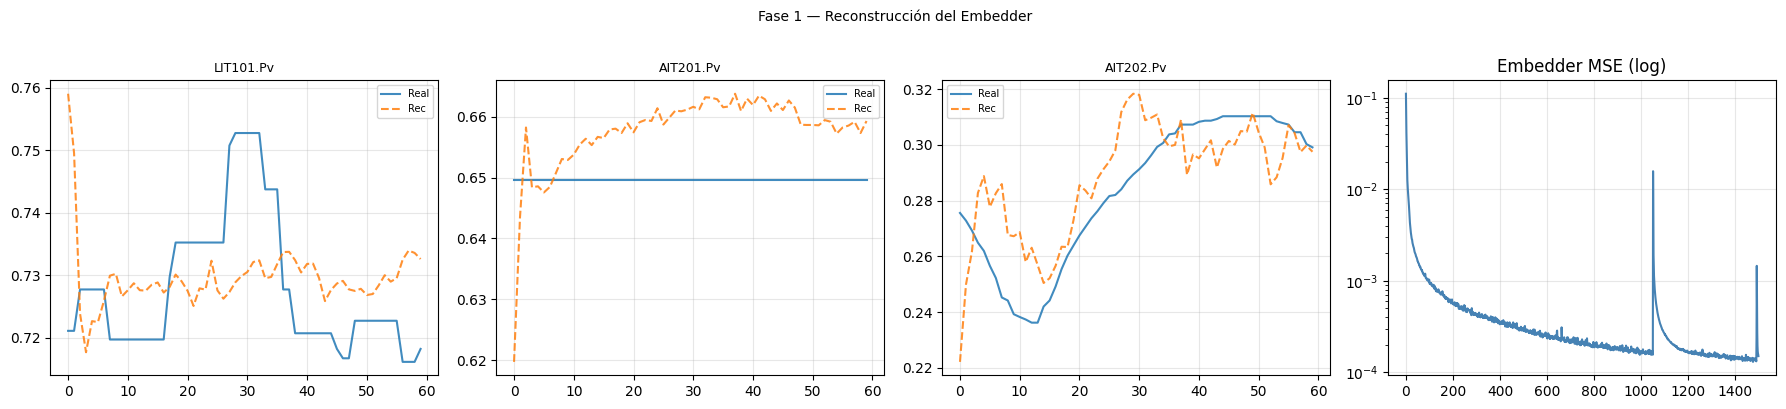

In [14]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1:4d}/{epochs_embedder} | MSE: {ep:.6f}")

mse_f = embedder_history[-1]
print(f"\nMSE final: {mse_f:.6f}  {'✅' if mse_f < 0.001 else '⚠️ '}")

with torch.no_grad():
    xs = train_tensor[:64].to(device)
    xr = recovery(embedder(xs)).cpu().numpy()
    xo = xs.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(xo[0,:,idx], label="Real", alpha=0.85)
    axes[idx].plot(xr[0,:,idx], label="Rec",  alpha=0.85, linestyle="--")
    axes[idx].set_title(GAN_CONT_COLS[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True, alpha=0.3)
axes[3].semilogy(embedder_history, color="steelblue")
axes[3].set_title("Embedder MSE (log)"); axes[3].grid(True, alpha=0.3)
plt.suptitle("Fase 1 — Reconstrucción del Embedder", fontsize=10, y=1.01)
plt.tight_layout(); plt.show()


## D1. Diagnóstico del Embedder — Calidad de Reconstrucción

Este diagnóstico responde: **¿el espacio latente representa fielmente los datos?**

Si la reconstrucción `x -> Embedder -> Recovery -> x_hat` tiene RMSE alto,
significa que h_real no contiene suficiente informacion del dato original.
En ese caso, todo el entrenamiento adversarial trabaja sobre representaciones
incorrectas y el generador no puede aprender la distribucion real.

**Criterio:** RMSE < 0.05 por sensor = OK. RMSE > 0.10 = el embedding es inadecuado.


=== D1: DIAGNOSTICO EMBEDDER — CALIDAD DE RECONSTRUCCION ===

Sensor                       MSE        RMSE  Estado
----------------------------------------------------
LIT101.Pv               0.000116     0.01078  OK
AIT201.Pv               0.000124     0.01111  OK
AIT202.Pv               0.000145     0.01205  OK
AIT203.Pv               0.000089     0.00942  OK
AIT301.Pv               0.000117     0.01083  OK
AIT302.Pv               0.000096     0.00981  OK
AIT303.Pv               0.000187     0.01367  OK
LIT301.Pv               0.000161     0.01269  OK
DPIT301.Pv              0.000363     0.01907  OK
LIT401.Pv               0.000086     0.00926  OK
AIT402.Pv               0.000175     0.01324  OK
AIT501.Pv               0.000197     0.01404  OK
AIT502.Pv               0.000096     0.00982  OK
AIT503.Pv               0.000090     0.00950  OK
AIT504.Pv               0.000170     0.01305  OK
PIT501.Pv               0.000158     0.01256  OK
PIT502.Pv               0.000046     0.00675  OK

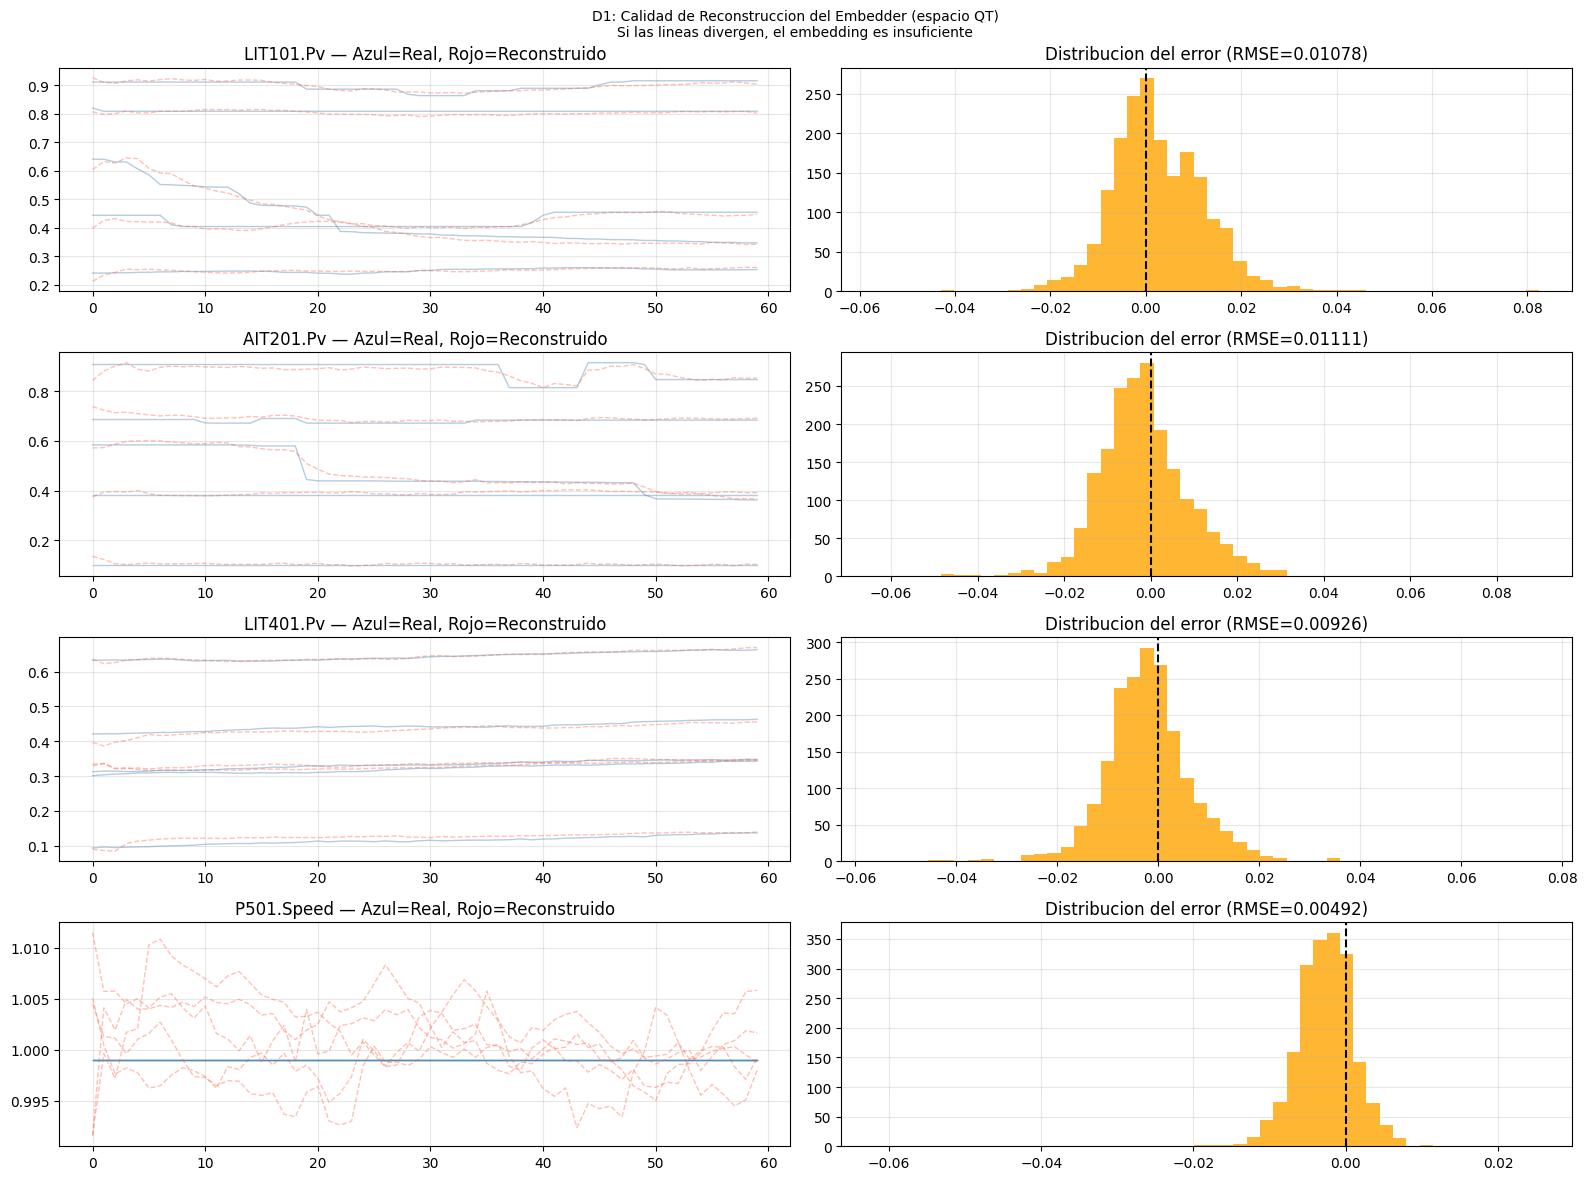

In [15]:
print("=== D1: DIAGNOSTICO EMBEDDER — CALIDAD DE RECONSTRUCCION ===")
print()

# Muestra de 32 ventanas reales: encode -> decode
with torch.no_grad():
    x_samp = next(iter(train_loader))[0][:32].to(device)
    h_samp  = embedder(x_samp)
    x_rec   = recovery(h_samp).cpu().numpy()
x_samp_np = x_samp.cpu().numpy()

# MSE por sensor
mse_per = ((x_samp_np - x_rec)**2).mean(axis=(0,1))  # (feature_dim,)

print(f'{"Sensor":<20}  {"MSE":>10}  {"RMSE":>10}  Estado')
print("-" * 52)
for j, s in enumerate(GAN_CONT_COLS):
    rmse = mse_per[j]**0.5
    est  = "OK" if rmse < 0.05 else ("REVISAR" if rmse < 0.10 else "MAL")
    print(f'{s:<20}  {mse_per[j]:>10.6f}  {rmse:>10.5f}  {est}')
print()
print(f"MSE global: {mse_per.mean():.6f} | RMSE global: {mse_per.mean()**0.5:.5f}")
print(f"Referencia A7 v21 MSE final: 0.000121")
print()

# Visualizacion: real vs reconstruido para 4 sensores clave
plot_s = [s for s in ["LIT101.Pv","AIT201.Pv","LIT401.Pv","P501.Speed"] if s in GAN_CONT_COLS]
fig, axes = plt.subplots(len(plot_s), 2, figsize=(16, 3*len(plot_s)))
if len(plot_s) == 1: axes = [axes]
for k, s in enumerate(plot_s):
    j = GAN_CONT_COLS.index(s)
    for w in range(min(5, 32)):
        axes[k][0].plot(x_samp_np[w,:,j], alpha=0.4, lw=1, color="steelblue")
        axes[k][0].plot(x_rec[w,:,j],     alpha=0.4, lw=1, color="tomato",  linestyle="--")
    axes[k][0].set_title(f"{s} — Azul=Real, Rojo=Reconstruido")
    axes[k][0].grid(True, alpha=0.3)
    diff = (x_samp_np[:,:,j] - x_rec[:,:,j]).flatten()
    axes[k][1].hist(diff, bins=50, color="orange", alpha=0.8, edgecolor="none")
    axes[k][1].axvline(0, color="black", lw=1.5, linestyle="--")
    axes[k][1].set_title(f"Distribucion del error (RMSE={mse_per[j]**0.5:.5f})")
    axes[k][1].grid(True, alpha=0.3)
plt.suptitle("D1: Calidad de Reconstruccion del Embedder (espacio QT)\n"
             "Si las lineas divergen, el embedding es insuficiente", fontsize=10)
plt.tight_layout(); plt.show()


## 10b. Preentrenamiento del Generador (300 épocas) — Fix D3

**Motivación:** en v14, el t-SNE del espacio latente (D3) mostró que `h_synth` era un
blob compacto completamente separado de `h_real`. La causa raíz: G inicia desde
pesos aleatorios y produce representaciones latentes que no se parecen a `h_real`.

**El fix:** pre-entrenar G durante 300 épocas para minimizar `MSE(G(z), h_real)`.
Con el embedder ya convergido (MSE~0.00015), `h_real` es una representación fiel
del espacio latente real. Al minimizar la distancia entre `G(z)` y muestras aleatorias
de `h_real`, el generador aprende a producir vectores latentes que cubren el manifold
real ANTES de que empiece la competencia adversarial.

**Resultado esperado:** cuando empiece el joint training, G ya produce h cercanos
a h_real. D tendra que trabajar más duramente para distinguirlos -> equilibrio más
estable -> D no explota -> G no colapsa -> h_synth solapa con h_real en t-SNE.

**Nota tecnica:** se usa un optimizador Adam separado con lr=1e-3 (más agresivo)
para el pre-entrenamiento. No interfiere con g_optimizer ni su scheduler,
que se usan exclusivamente en el joint training.


=== PREENTRENAMIENTO DEL GENERADOR (Fix D3) ===

Computando h_real para todo el train...
h_real_all: torch.Size([2944, 60, 128])

[G Pretrain] Epoch  50/300 | MSE: 0.037394
[G Pretrain] Epoch 100/300 | MSE: 0.037362
[G Pretrain] Epoch 150/300 | MSE: 0.037356
[G Pretrain] Epoch 200/300 | MSE: 0.037370
[G Pretrain] Epoch 250/300 | MSE: 0.037318
[G Pretrain] Epoch 300/300 | MSE: 0.037330

MSE inicial:  0.052087
MSE final:    0.037330
Reduccion:    28.3%



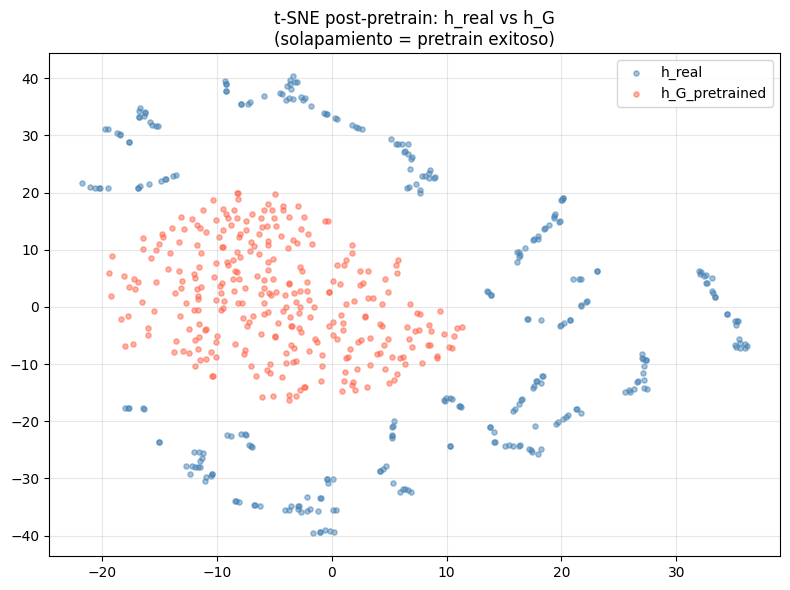

Si hay solapamiento, el pretrain fue exitoso -> joint training parte de buen punto.
Si aun separado, el pretrain necesita mas epochs o lr diferente.


In [16]:
print("=== PREENTRENAMIENTO DEL GENERADOR (Fix D3) ===")
print()

# Paso 1: computar todos los h_real con el embedder ya convergido
print("Computando h_real para todo el train...")
h_real_all_list = []
with torch.no_grad():
    for batch in train_loader:
        x_b = batch[0].to(device)
        h_real_all_list.append(embedder(x_b).cpu())
h_real_all = torch.cat(h_real_all_list, dim=0)  # (N_train, seq_len, hidden_dim)
print(f"h_real_all: {h_real_all.shape}")
print()

# Paso 2: pre-entrenar G con optimizer separado (lr alto para convergencia rapida)
gen_pretrain_opt = torch.optim.Adam(generator.parameters(), lr=1e-3)
pretrain_history = []

for epoch in range(GEN_PRETRAIN_EPOCHS):
    ep_loss = 0.0
    perm = torch.randperm(len(h_real_all))
    for start in range(0, len(h_real_all), BATCH_SIZE):
        end   = min(start + BATCH_SIZE, len(h_real_all))
        bs    = end - start
        h_tgt = h_real_all[perm[start:end]].to(device)
        z     = random_z_clipped(bs, seq_len, latent_dim, device)
        h_hat = generator(z)
        loss  = mse_loss(h_hat, h_tgt)
        gen_pretrain_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(generator.parameters(), G_CLIP)
        gen_pretrain_opt.step()
        ep_loss += loss.item()
    ep_loss /= len(train_loader)
    pretrain_history.append(ep_loss)
    if (epoch + 1) % 50 == 0:
        print(f"[G Pretrain] Epoch {epoch+1:3d}/{GEN_PRETRAIN_EPOCHS} | MSE: {ep_loss:.6f}")

print()
print(f"MSE inicial:  {pretrain_history[0]:.6f}")
print(f"MSE final:    {pretrain_history[-1]:.6f}")
print(f"Reduccion:    {100*(pretrain_history[0]-pretrain_history[-1])/max(pretrain_history[0],1e-10):.1f}%")
print()

# Verificacion visual: h_real vs h_pretrained en t-SNE (muestra rapida)
import warnings
from sklearn.manifold import TSNE as _TSNE2
n_check = 300
rng_check = np.random.default_rng(7)
idx_check = rng_check.choice(len(h_real_all), n_check, replace=False)
h_real_s  = h_real_all[idx_check].mean(axis=1).numpy()
with torch.no_grad():
    z_chk = random_z_clipped(n_check, seq_len, latent_dim, device)
    h_pre_s = generator(z_chk).cpu().mean(axis=1).numpy()
H_pre = np.vstack([h_real_s, h_pre_s])
y_pre = np.array([0]*n_check + [1]*n_check)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    H_pre_2d = _TSNE2(n_components=2, perplexity=20, random_state=42, max_iter=500).fit_transform(H_pre)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(H_pre_2d[y_pre==0,0], H_pre_2d[y_pre==0,1], c="steelblue", alpha=0.5, s=14, label="h_real")
ax.scatter(H_pre_2d[y_pre==1,0], H_pre_2d[y_pre==1,1], c="tomato",    alpha=0.5, s=14, label="h_G_pretrained")
ax.set_title("t-SNE post-pretrain: h_real vs h_G\n(solapamiento = pretrain exitoso)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print("Si hay solapamiento, el pretrain fue exitoso -> joint training parte de buen punto.")
print("Si aun separado, el pretrain necesita mas epochs o lr diferente.")


## 11. Fase 2 — Preentrenamiento del Supervisor (600 épocas)

Con el embedder convergido (1500 epochs) y el generador pre-entrenado,
el espacio latente h es de alta calidad y G ya produce h cercanos a h_real.

El supervisor aprende la dinámica temporal: `h_{t+1} = S(h_t)`.
Con un h_real más representativo y G ya en la zona correcta, el supervisor
deberia converger a < 0.003 con 600 epochs (A7 v21: 0.002200 con 300 epochs).


In [17]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1:4d}/{epochs_supervisor} | Loss: {ep:.6f}")

sup_f = supervisor_history[-1]
print(f"\nLoss final: {sup_f:.6f}  {'✅' if sup_f < 0.005 else '⚠️ '}")


[Supervisor] Epoch  100/600 | Loss: 0.006331
[Supervisor] Epoch  200/600 | Loss: 0.005348
[Supervisor] Epoch  300/600 | Loss: 0.004637
[Supervisor] Epoch  400/600 | Loss: 0.004166
[Supervisor] Epoch  500/600 | Loss: 0.003822
[Supervisor] Epoch  600/600 | Loss: 0.003586

Loss final: 0.003586  ✅


## D2. Diagnóstico del Supervisor — Predicción Temporal

Este diagnóstico responde: **¿el supervisor generaliza la dinámica temporal?**

El supervisor aprende a predecir h_{t+1} dado h_t (teacher-forced).
Si el free-run (autoregressivo, sin teacher forcing) diverge mucho,
el supervisor no generaliza bien y el generador producira secuencias erraticas.

**Criterio:** ratio free-run/teacher-forced < 10x = aceptable.


=== D2: DIAGNOSTICO SUPERVISOR — PREDICCION TEMPORAL ===

Teacher-forced MSE: 0.003674
Free-run MSE:       0.020767
Ratio free/tf:      5.65x

Supervisor: ACEPTABLE generalizacion



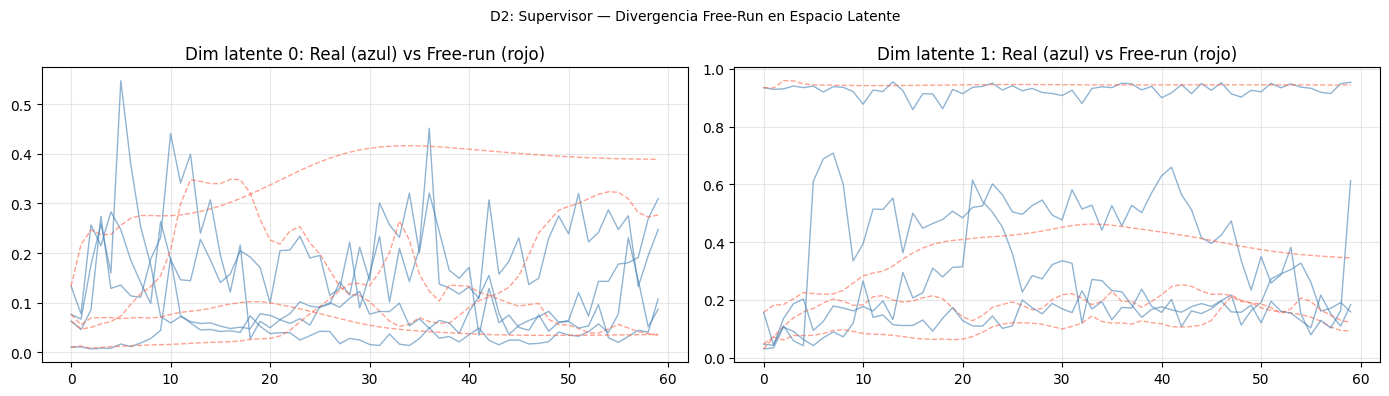

In [18]:
print("=== D2: DIAGNOSTICO SUPERVISOR — PREDICCION TEMPORAL ===")
print()

with torch.no_grad():
    x_b = next(iter(train_loader))[0][:16].to(device)
    h_b = embedder(x_b)  # (16, 60, hidden)

    # Teacher-forced: supervisor ve h_real en cada paso
    h_pred_tf = supervisor(h_b)
    tf_loss   = ((h_b[:, 1:, :] - h_pred_tf[:, :-1, :])**2).mean().item()

    # Free-run: autoregresivo desde h_0
    h_seq = h_b[:, :1, :]  # primer paso (seed real)
    preds = [h_seq]
    for _ in range(59):           # ← antes era 58
        h_next = supervisor(h_seq)[:, -1:, :]
        preds.append(h_next)
        h_seq  = torch.cat([h_seq, h_next], dim=1)
    h_free    = torch.cat(preds, dim=1)  # (16, 60, hidden)  ← antes era 59
    free_loss = ((h_b[:, 1:, :] - h_free[:, 1:, :])**2).mean().item()
ratio = free_loss / max(tf_loss, 1e-10)
print(f"Teacher-forced MSE: {tf_loss:.6f}")
print(f"Free-run MSE:       {free_loss:.6f}")
print(f"Ratio free/tf:      {ratio:.2f}x")
print()
if ratio < 5:    print("Supervisor: EXCELENTE generalizacion temporal")
elif ratio < 15: print("Supervisor: ACEPTABLE generalizacion")
else:            print("Supervisor: ALERTA - alta divergencia en free-run")
print()

# Visualizacion: h_real vs h_free-run en las primeras 2 dims del latente
h_b_np    = h_b.cpu().numpy()
h_free_np = h_free.cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for w in range(4):
    axes[0].plot(h_b_np[w, :, 0],    alpha=0.6, lw=1, color="steelblue")
    axes[0].plot(h_free_np[w, :, 0], alpha=0.6, lw=1, color="tomato", linestyle="--")
axes[0].set_title("Dim latente 0: Real (azul) vs Free-run (rojo)")
axes[0].grid(True, alpha=0.3)
for w in range(4):
    axes[1].plot(h_b_np[w, :, 1],    alpha=0.6, lw=1, color="steelblue")
    axes[1].plot(h_free_np[w, :, 1], alpha=0.6, lw=1, color="tomato", linestyle="--")
axes[1].set_title("Dim latente 1: Real (azul) vs Free-run (rojo)")
axes[1].grid(True, alpha=0.3)
plt.suptitle("D2: Supervisor — Divergencia Free-Run en Espacio Latente", fontsize=10)
plt.tight_layout(); plt.show()


## 12. Fase 3 — Entrenamiento adversarial conjunto (1500 épocas)

**Objetivo:** que el Generator produzca series indistinguibles de las reales.

### Función de pérdida

```
L_G = BCE(D(H_hat), 1) + gamma x BCE(D(E_hat), 1)
    + eta x ||h_{t+1} - S(h_t)||^2
    + FM_W x (||mu_real-mu_synth||^2 + ||sigma_real-sigma_synth||^2)

L_D = BCE(D(H_real),1) + BCE(D(H_fake),0) + gamma x BCE(D(E_hat),0)
    + R1_LAMBDA x R1_INTERVAL x ||nabla D(h_real)||^2
```

Identica a v12 / A7 v21. Con feature_dim=21 el espacio latente es mas limpio
-> se espera que D oscile de forma estable cerca del Nash (como en A7),
con muchos menos spikes que los 851 de v12.

**Referencia A7 v21:** D_final=2.0751 (Nash exacto) | Spikes=104.


In [19]:
def r1_penalty(disc, h_real):
    h_r  = h_real.detach().requires_grad_(True)
    y_r  = disc(h_r)
    grad = torch.autograd.grad(outputs=y_r.sum(), inputs=h_r,
                                create_graph=False, retain_graph=False)[0]
    return grad.pow(2).mean()


joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # ── G: G_STEPS pasos ────────────────────────────────────────────────────
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            z     = random_z_clipped(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat)
            y_fe  = discriminator(e_hat)
            g_u   = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue  = bce_loss(y_fe, torch.ones_like(y_fe))
            with torch.no_grad():
                h_sup = supervisor(h_real)
            g_s     = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])
            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))
            # v12: sin FM_INTRA_W (eliminado, no presente en A7 v21)
            g_loss = g_u + gamma * g_ue + eta * g_s + FM_W * fm_loss
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), G_CLIP)
            g_optimizer.step()
            g_loss_val = g_loss

        # ── Embedder refinement ──────────────────────────────────────────────────
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :])
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0)
        e_optimizer.step()

        batch_counter += 1

        # ── D: D_STEPS pasos con R1 lazy ─────────────────────────────────────────
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()
            with torch.no_grad():
                z2     = random_z_clipped(bs, seq_len, latent_dim, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)
            y_r   = discriminator(h_real)
            y_f2  = discriminator(h_hat2)
            y_fe2 = discriminator(e_hat2)
            r1 = r1_penalty(discriminator, h_real) if batch_counter % R1_INTERVAL == 0 \
                 else torch.tensor(0.0, device=device)
            d_loss = (bce_loss(y_r,   torch.ones_like(y_r)) +
                      bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                      gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                      R1_LAMBDA * R1_INTERVAL * r1)
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), D_CLIP)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)
    g_scheduler.step(g_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev-0.05 else ("↑" if g_ep > g_prev+0.1 else "→")
        print(f"[Joint] Epoch {epoch+1:5d}/{epochs_joint} | "
              f"G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch   100/1500 | G: 2.4017↑ | D: 1.5029 | E: 0.003932
[Joint] Epoch   200/1500 | G: 2.4008→ | D: 1.2660 | E: 0.002554
[Joint] Epoch   300/1500 | G: 1.4917↓ | D: 1.6197 | E: 0.002180
[Joint] Epoch   400/1500 | G: 2.2686↑ | D: 1.5310 | E: 0.001873
[Joint] Epoch   500/1500 | G: 2.8587↑ | D: 1.1337 | E: 0.001887
[Joint] Epoch   600/1500 | G: 3.1831↑ | D: 1.1132 | E: 0.001933
[Joint] Epoch   700/1500 | G: 3.3893↑ | D: 2.2406 | E: 0.002890
[Joint] Epoch   800/1500 | G: 3.1797↓ | D: 1.4652 | E: 0.005177
[Joint] Epoch   900/1500 | G: 2.1590↓ | D: 1.6623 | E: 0.001371
[Joint] Epoch  1000/1500 | G: 1.9392↓ | D: 1.7603 | E: 0.000963
[Joint] Epoch  1100/1500 | G: 2.3684↑ | D: 2.4992 | E: 0.004299
[Joint] Epoch  1200/1500 | G: 1.8782↓ | D: 2.7554 | E: 0.001888
[Joint] Epoch  1300/1500 | G: 1.8446→ | D: 1.6616 | E: 0.001757
[Joint] Epoch  1400/1500 | G: 1.5703↓ | D: 1.5903 | E: 0.000747
[Joint] Epoch  1500/1500 | G: 1.6327→ | D: 1.6001 | E: 0.000537


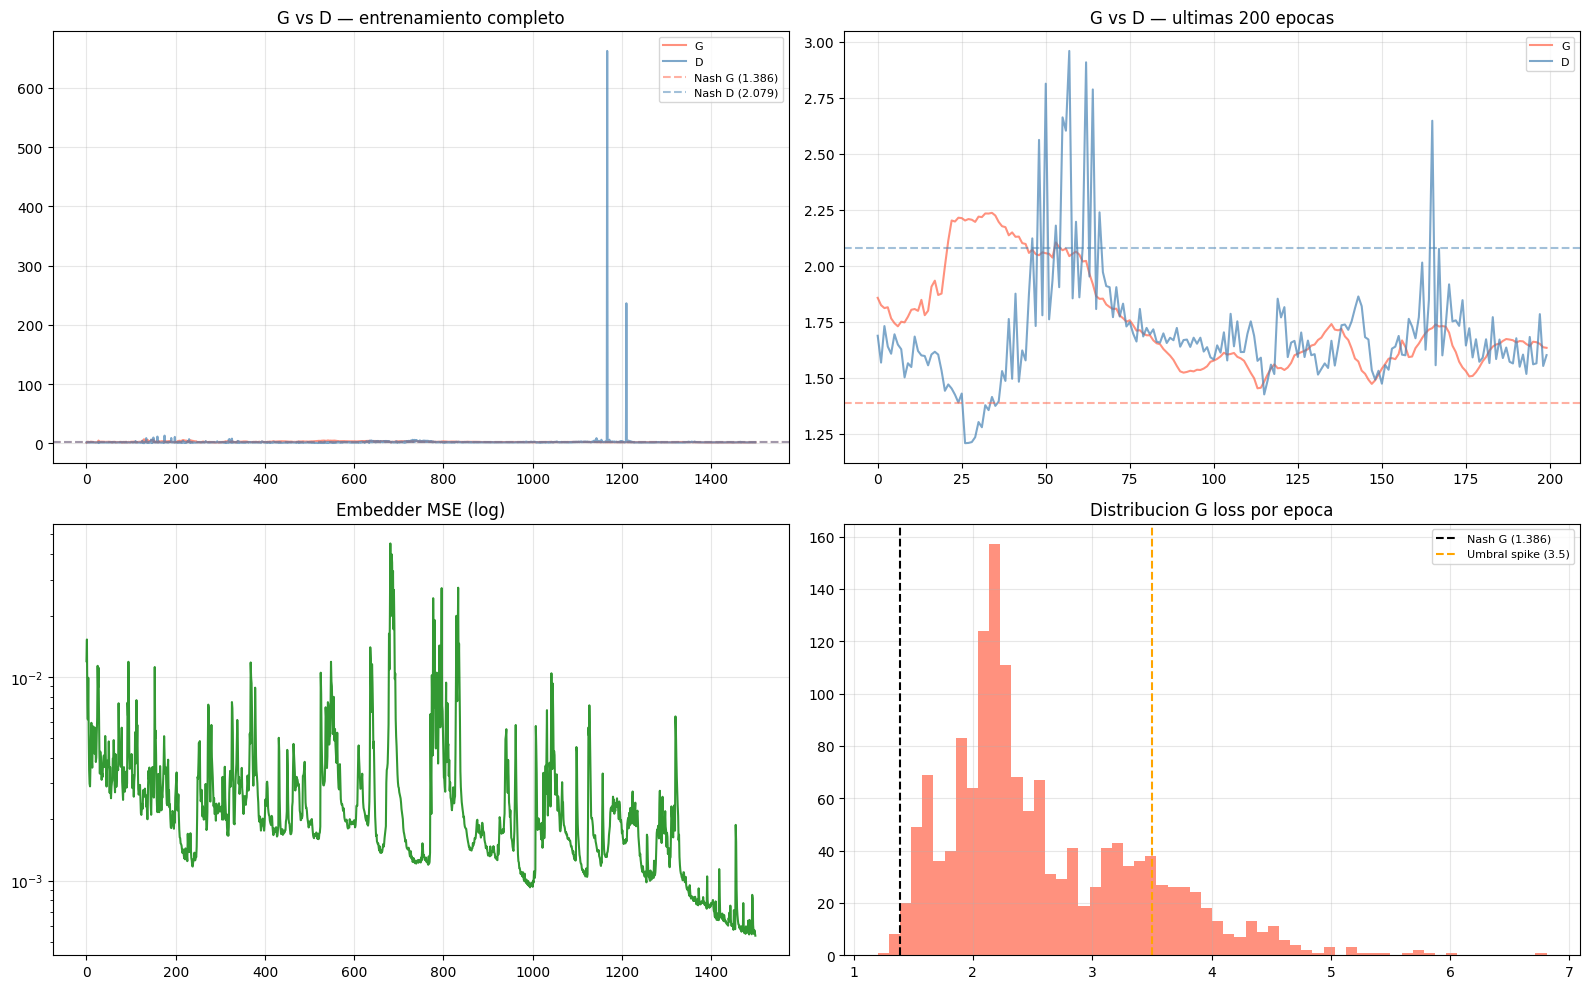

G inicial:    1.2024  (Nash G=1.3863)
G final:      1.6327  (Nash G = 1.3863)
D final:      1.6001  (Nash D = 2.0794, gap=0.4794)
Spikes G>3.5: 224

Referencia A7 v21: G_final=2.7714 | D_final=2.0751 | Spikes=104
v12 estado.....D alejado de Nash - revisar


In [20]:
# ── Graficas del entrenamiento ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(joint_g_history, alpha=0.7, color="tomato",    label="G")
axes[0,0].plot(joint_d_history, alpha=0.7, color="steelblue", label="D")
axes[0,0].axhline(nash_g, color="tomato",    linestyle="--", alpha=0.5, label=f"Nash G ({nash_g:.3f})")
axes[0,0].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5, label=f"Nash D ({nash_d:.3f})")
axes[0,0].set_title("G vs D — entrenamiento completo"); axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(joint_g_history[-200:], alpha=0.7, color="tomato",    label="G")
axes[0,1].plot(joint_d_history[-200:], alpha=0.7, color="steelblue", label="D")
axes[0,1].axhline(nash_g, color="tomato",    linestyle="--", alpha=0.5)
axes[0,1].axhline(nash_d, color="steelblue", linestyle="--", alpha=0.5)
axes[0,1].set_title("G vs D — ultimas 200 epocas"); axes[0,1].legend(fontsize=8); axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1,0].set_title("Embedder MSE (log)"); axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(joint_g_history, bins=60, color="tomato", alpha=0.7, edgecolor="none")
axes[1,1].axvline(nash_g, color="black",  linestyle="--", lw=1.5, label=f"Nash G ({nash_g:.3f})")
axes[1,1].axvline(3.5,    color="orange", linestyle="--", lw=1.5, label="Umbral spike (3.5)")
axes[1,1].set_title("Distribucion G loss por epoca"); axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ── Resumen de estado final ─────────────────────────────────────────────────
# v12: sin best-checkpoint. Se usa el estado final del training.
# Con el modelo del tamano correcto (A7-style), el estado final deberia ser bueno.
g_f = joint_g_history[-1]; d_f = joint_d_history[-1]
spikes = sum(1 for g in joint_g_history if g > 3.5)

print(f"G inicial:    {joint_g_history[0]:.4f}  (Nash G={nash_g:.4f})")
print(f"G final:      {g_f:.4f}  (Nash G = {nash_g:.4f})")
print(f"D final:      {d_f:.4f}  (Nash D = {nash_d:.4f}, gap={abs(d_f-nash_d):.4f})")
print(f"Spikes G>3.5: {spikes}")
print()
print(f"Referencia A7 v21: G_final=2.7714 | D_final=2.0751 | Spikes=104")
print(
    f"v12 estado.....{'OK - D cercano a Nash' if abs(d_f - nash_d) < 0.3 else 'D alejado de Nash - revisar'}"
)


## D3. Diagnóstico del Generador — t-SNE del Espacio Latente

Este diagnóstico responde: **¿El generador aprende bien el espacio latente h?**

Compara h_real=Embedder(x_real) vs h_synth=Supervisor(Generator(z)) directamente.
Si hay solapamiento en este plot pero no en el QT, el problema está en Recovery.
Si hay separación también aqui, el generador no aprende el espacio latente.

Tambien calcula la **correlación de Pearson** entre los estados latentes
real y sintético por cada timestep — ideal: cercana a cero (independiente pero similar).


=== D3: DIAGNOSTICO GENERADOR — t-SNE ESPACIO LATENTE ===



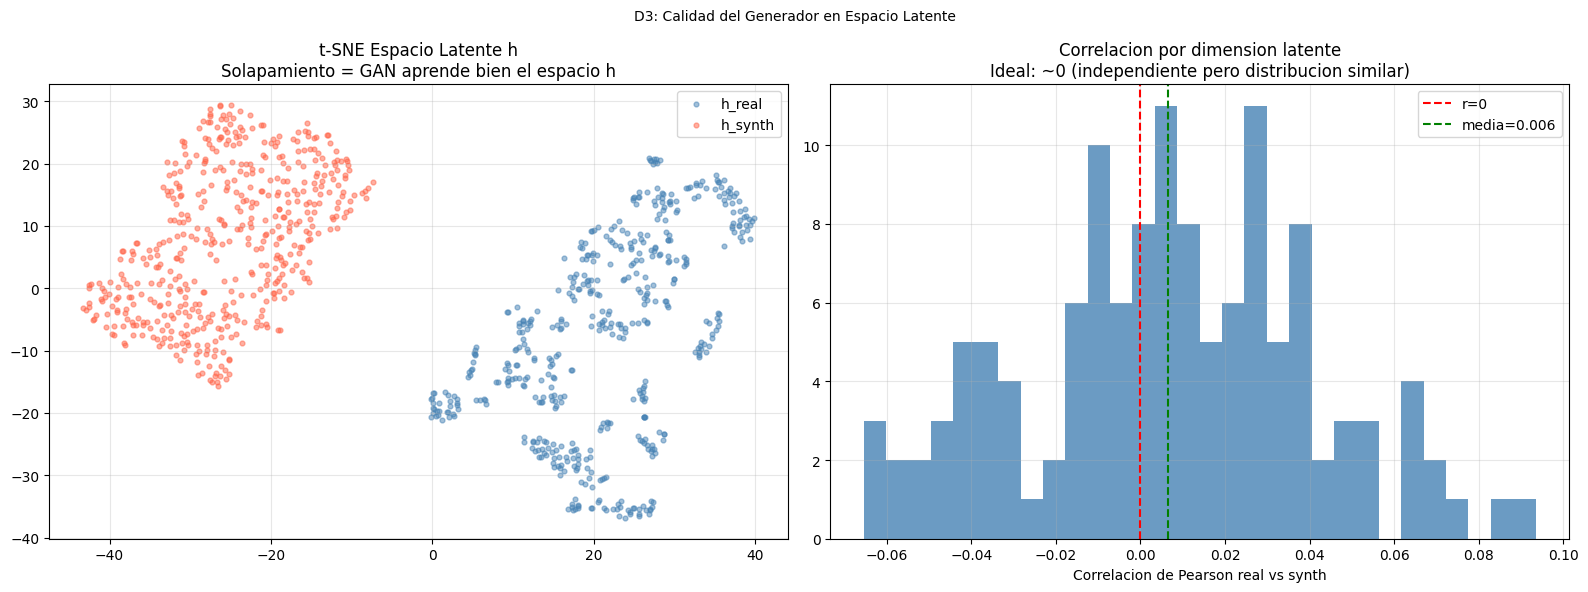

Correlacion media h_real vs h_synth: 0.0064
Dims con r > 0.3 (covarianza excesiva): 0
Dims con r < -0.3 (colapso de modo):   0

Interpretacion:
  Si t-SNE latente SOLAPA pero t-SNE QT SEPARA -> problema en Recovery
  Si t-SNE latente SEPARA -> generador no aprende bien el espacio h


In [21]:
import warnings
from sklearn.manifold import TSNE as _TSNE

print("=== D3: DIAGNOSTICO GENERADOR — t-SNE ESPACIO LATENTE ===")
print()

n_lat = 500
rng_l = np.random.default_rng(42)
idx_l = rng_l.choice(len(train_windows), n_lat, replace=False)

with torch.no_grad():
    x_r = torch.tensor(train_windows[idx_l], dtype=torch.float32).to(device)
    h_r = embedder(x_r).cpu().numpy()           # (500, 60, hidden)
    z_s = random_z_clipped(n_lat, seq_len, latent_dim, device)
    h_s = supervisor(generator(z_s)).cpu().numpy()  # (500, 60, hidden)

# Mean-pool sobre tiempo -> (500, hidden)
hr_mp = h_r.mean(axis=1)
hs_mp = h_s.mean(axis=1)

# t-SNE
H_all = np.vstack([hr_mp, hs_mp])
y_all = np.array([0]*n_lat + [1]*n_lat)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    H2d = _TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000).fit_transform(H_all)

# Correlacion por dimension latente
corr_dims = [np.corrcoef(hr_mp[:,d], hs_mp[:,d])[0,1] for d in range(hr_mp.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(H2d[y_all==0,0], H2d[y_all==0,1], c="steelblue", alpha=0.5, s=12, label="h_real")
axes[0].scatter(H2d[y_all==1,0], H2d[y_all==1,1], c="tomato",    alpha=0.5, s=12, label="h_synth")
axes[0].set_title("t-SNE Espacio Latente h\nSolapamiento = GAN aprende bien el espacio h")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(corr_dims, bins=30, color="steelblue", edgecolor="none", alpha=0.8)
axes[1].axvline(0,                  color="red",   linestyle="--", lw=1.5, label="r=0")
axes[1].axvline(np.mean(corr_dims), color="green", linestyle="--", lw=1.5,
                label=f"media={np.mean(corr_dims):.3f}")
axes[1].set_xlabel("Correlacion de Pearson real vs synth")
axes[1].set_title("Correlacion por dimension latente\nIdeal: ~0 (independiente pero distribucion similar)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle("D3: Calidad del Generador en Espacio Latente", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Correlacion media h_real vs h_synth: {np.mean(corr_dims):.4f}")
print(f"Dims con r > 0.3 (covarianza excesiva): {sum(1 for r in corr_dims if r > 0.3)}")
print(f"Dims con r < -0.3 (colapso de modo):   {sum(1 for r in corr_dims if r < -0.3)}")
print()
print("Interpretacion:")
print("  Si t-SNE latente SOLAPA pero t-SNE QT SEPARA -> problema en Recovery")
print("  Si t-SNE latente SEPARA -> generador no aprende bien el espacio h")


## 13. Generación de datos sintéticos

### Proceso de generación

1. Se samplea ruido `z ~ U(0.001, 0.999)` de longitud `seq_len`
2. El Generator produce representaciones latentes `e_hat = G(z)` (21 features)
3. El Supervisor refina la dinámica temporal: `h_hat = S(e_hat)`
4. La Recovery convierte al espacio QT: `x_hat = R(h_hat)` (shape: N x 60 x 21)
5. Se clipea a [0.0, 1.0]
6. `qt.inverse_transform()` -> escala fisica (21 features)
7. **Sintesis empirica condicional** para los 10 FIT (bimodales)
8. **Sintesis empirica con persistencia** para variables discretas
9. Ensamble en el orden del detector (31 continuas)

### Sensores FIT: todos por sintesis empirica en v13

| FIT | v12 | v13 | Justificacion |
|-----|-----|-----|---------------|
| FIT101, 201, 301, 601 | Empirico | Empirico | sin cambio |
| FIT401, 501, 502, 503, 504, 602 | **GAN** | **Empirico** | bimodales, contaminaban espacio latente |

La sintesis empirica genera ventanas de 60 timesteps para cada FIT
muestreando P(valvula=0) del catalogo real, con persistencia de estado
(probabilidad 3% de cambio de estado en cada timestep).


In [22]:
# v12: sintesis estandar sin burn-in (igual que A7 v21)
# Con hidden_dim=128 y R1_LAMBDA=0.01, no se espera cold-start.

n_synth = len(train_windows)
synth_qt_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end = min(start + 256, n_synth)
        bs  = end - start
        z      = random_z_clipped(bs, seq_len, latent_dim, device)
        x_hat  = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)

synth_qt = np.concatenate(synth_qt_list, axis=0)  # (n_synth, seq_len, feature_dim)

out_rng = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"synth_qt shape: {synth_qt.shape}")
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%  {chr(9989) if out_rng < 1.0 else chr(9888)}")

synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias QT (pre-QM): {dm:.4f}  {chr(9989) if dm<0.05 else chr(9888)}")
print(f"Diff stds  QT (pre-QM): {ds:.4f}  {chr(9989) if ds<0.10 else chr(9888)}")
print(f"Referencia A7 v21:  diff_medias=0.0048 | diff_stds=0.0206")


synth_qt shape: (3063, 60, 21)
Rango pre-clip: [-0.1707, 1.3535]
Fuera de [-0.1, 1.1]: 0.04%  ✅
Diff medias QT (pre-QM): 0.0073  ✅
Diff stds  QT (pre-QM): 0.0221  ✅
Referencia A7 v21:  diff_medias=0.0048 | diff_stds=0.0206


## D4. Diagnóstico Pre-QM — Drift por Sensor

Tabla detallada de drift y ratio de varianza intra-ventana antes de aplicar QM.
Permite identificar qué sensores tienen problemas estructurales vs marginales.

- **|dm|** alto (>0.10): drift de media — el generador usa el rango equivocado
- **ratio_intra** alto (>3x): drift intra-ventana — el GRU genera random walks
- Ambos altos: el sensor es fundamentalmente difícil de modelar con este GAN


=== D4: DIAGNOSTICO PRE-QM POR SENSOR ===

Sensor                     dm       ds   intra_r   intra_s    ratio  Estado
--------------------------------------------------------------------------------
LIT101.Pv              0.0561   0.0368   0.02023   0.03264     1.61x  REVISAR
AIT201.Pv              0.0385   0.0615   0.01590   0.02647     1.67x  OK
AIT202.Pv              0.0530   0.0571   0.05855   0.06396     1.09x  REVISAR
AIT203.Pv              0.0592   0.0423   0.01088   0.02428     2.23x  REVISAR
AIT301.Pv              0.0199   0.0239   0.01882   0.02285     1.21x  OK
AIT302.Pv              0.0456   0.0233   0.00851   0.02236     2.63x  REVISAR
AIT303.Pv              0.0314   0.0047   0.01000   0.02266     2.27x  OK
LIT301.Pv              0.1719   0.0378   0.02025   0.03036     1.50x  MAL
DPIT301.Pv             0.1619   0.0751   0.06567   0.04541     0.69x  MAL
LIT401.Pv              0.0892   0.0953   0.01302   0.02612     2.01x  REVISAR
AIT402.Pv              0.0091   0.0096   0.

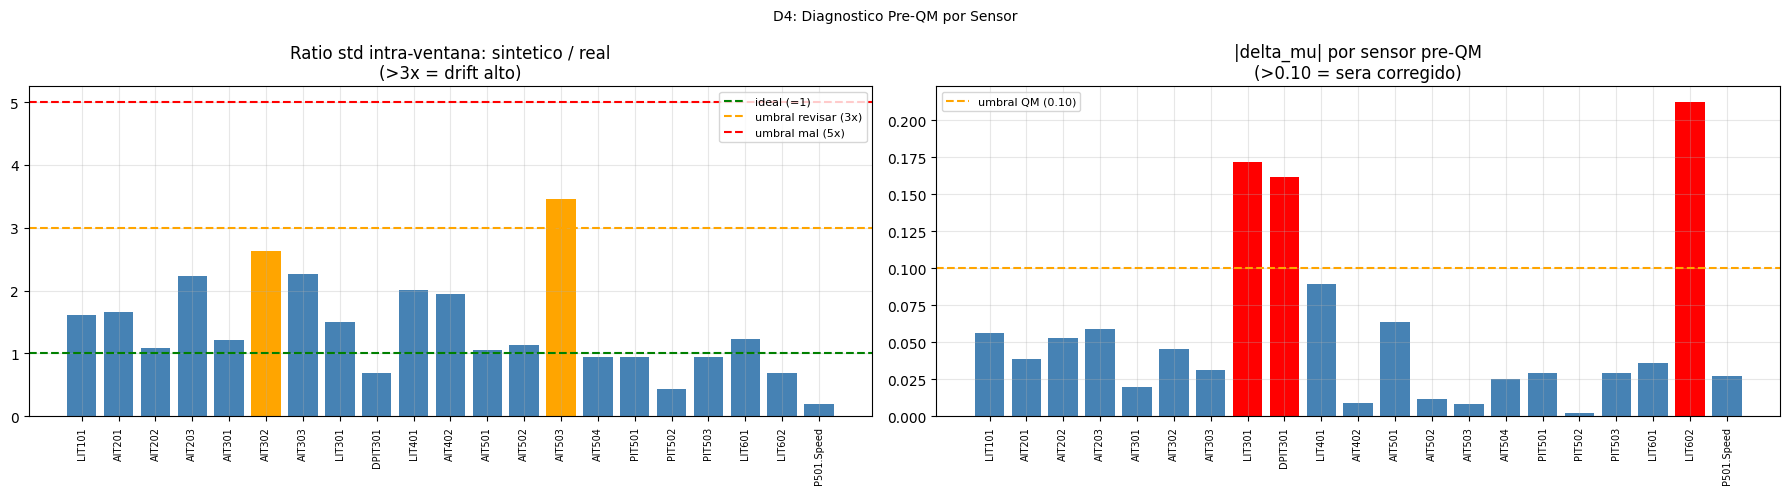

In [23]:
print("=== D4: DIAGNOSTICO PRE-QM POR SENSOR ===")
print()

_rf = train_windows.reshape(-1, len(GAN_CONT_COLS))
_sf = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
dm_p      = np.abs(_rf.mean(0) - _sf.mean(0))
ds_p      = np.abs(_rf.std(0)  - _sf.std(0))
intra_r   = train_windows.std(axis=1).mean(axis=0)
intra_s   = synth_qt_clipped.std(axis=1).mean(axis=0)
ratio_i   = intra_s / np.maximum(intra_r, 1e-8)

print(f'{"Sensor":<20}  {"dm":>7}  {"ds":>7}  {"intra_r":>8}  {"intra_s":>8}  {"ratio":>7}  Estado')
print("-" * 80)
for j, s in enumerate(GAN_CONT_COLS):
    if dm_p[j]>0.10 or ds_p[j]>0.15 or ratio_i[j]>5.0:  est = "MAL"
    elif dm_p[j]>0.05 or ds_p[j]>0.08 or ratio_i[j]>2.5: est = "REVISAR"
    else:                                                   est = "OK"
    print(f'{s:<20}  {dm_p[j]:>7.4f}  {ds_p[j]:>7.4f}  {intra_r[j]:>8.5f}  '
          f'{intra_s[j]:>8.5f}  {ratio_i[j]:>7.2f}x  {est}')

n_mal = sum(1 for j in range(len(GAN_CONT_COLS))
           if dm_p[j]>0.10 or ds_p[j]>0.15 or ratio_i[j]>5.0)
print()
print(f"Sensores MAL:    {n_mal}/{len(GAN_CONT_COLS)}")
print(f"dm global:       {dm_p.mean():.4f}  (A7 v21: 0.0048)")
print(f"ratio_intra max: {ratio_i.max():.2f}x  (v13: 22x | A7: ~1x)")
print(f"ratio_intra med: {np.median(ratio_i):.2f}x")
print()

# Bar chart del ratio intra-ventana
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
colors = ["red" if r>5 else ("orange" if r>2.5 else "steelblue") for r in ratio_i]
axes[0].bar(range(len(GAN_CONT_COLS)), ratio_i, color=colors)
axes[0].axhline(1.0, color="green", linestyle="--", lw=1.5, label="ideal (=1)")
axes[0].axhline(3.0, color="orange",linestyle="--", lw=1.5, label="umbral revisar (3x)")
axes[0].axhline(5.0, color="red",   linestyle="--", lw=1.5, label="umbral mal (5x)")
axes[0].set_xticks(range(len(GAN_CONT_COLS)))
axes[0].set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
axes[0].set_title("Ratio std intra-ventana: sintetico / real\n(>3x = drift alto)")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(GAN_CONT_COLS)), dm_p, color=["red" if d>0.1 else "steelblue" for d in dm_p])
axes[1].axhline(0.10, color="orange", linestyle="--", lw=1.5, label="umbral QM (0.10)")
axes[1].set_xticks(range(len(GAN_CONT_COLS)))
axes[1].set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
axes[1].set_title("|delta_mu| por sensor pre-QM\n(>0.10 = sera corregido)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle("D4: Diagnostico Pre-QM por Sensor", fontsize=10)
plt.tight_layout(); plt.show()


## 13b. Corrección de distribución marginal — Quantile Mapping

Con feature_dim=21 y el espacio latente libre de FIT bimodales, se espera
un drift de medias pre-QM mucho menor que en v12 (0.0346).

Se mantienen los thresholds conservadores de v12:
- `CORR_MEAN_THR = 0.10`
- `CORR_STD_THR  = 0.15`

Con menos drift generado, se espera corregir 5-10 sensores de los 21
(vs 17/27 en v12), preservando mejor las correlaciones cruzadas.


In [24]:
from scipy.stats import rankdata

# ── v11: Thresholds de corrección ────────────────────────────────────────────────────
# CORR_MEAN_THR: sin cambio (0.10).
# CORR_STD_THR:  0.10->0.15. Con FM_INTRA_W y detrending soft se esperan menos
# sensores con drift de std significativo. Umbral mas alto -> menos sensores
# corregidos -> mejor preservacion de correlaciones cruzadas entre sensores.
CORR_MEAN_THR = 0.10
CORR_STD_THR  = 0.15   # v11: 0.10->0.15

_real_flat_pre  = train_windows.reshape(-1, len(GAN_CONT_COLS))
_synth_flat_pre = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
_dm_pre = np.abs(_real_flat_pre.mean(0) - _synth_flat_pre.mean(0))
_ds_pre = np.abs(_real_flat_pre.std(0)  - _synth_flat_pre.std(0))
CORRECTION_SENSORS = [GAN_CONT_COLS[j] for j in range(len(GAN_CONT_COLS))
                      if _dm_pre[j] > CORR_MEAN_THR or _ds_pre[j] > CORR_STD_THR]

print(f'=== CORRECCION DE DISTRIBUCION MARGINAL (Quantile Mapping) ===')
print(f'Umbral |delta_mu| > {CORR_MEAN_THR}  o  |delta_sigma| > {CORR_STD_THR}')
print(f'Sensores detectados para correccion: {len(CORRECTION_SENSORS)} / {len(GAN_CONT_COLS)}')
print()
print(f'  {"Sensor":<20}  {"FlagM":>6}  {"|dm|":>8}  {"FlagS":>6}  {"|ds|":>8}')
print(f'  {"-"*20}  {"-"*6}  {"-"*8}  {"-"*6}  {"-"*8}')
for j, s in enumerate(GAN_CONT_COLS):
    flag_m = '|Dm|' if _dm_pre[j] > CORR_MEAN_THR else '    '
    flag_s = '|Ds|' if _ds_pre[j] > CORR_STD_THR  else '    '
    mark   = ' <- CORREGIR' if s in CORRECTION_SENSORS else ''
    print(f'  {s:<20}  {flag_m:>6}  {_dm_pre[j]:>8.4f}  {flag_s:>6}  {_ds_pre[j]:>8.4f}{mark}')
print()
print('Sensores a corregir:', CORRECTION_SENSORS)
print()

def quantile_mapping(synth_col_flat, real_col_flat):
    """Quantile mapping: fuerza synth a tener la misma CDF que real.

    Preserva el orden relativo (monotono) -> preserva autocorrelacion temporal.
    """
    real_sorted = np.sort(real_col_flat)
    n_real      = len(real_sorted)
    ranks       = rankdata(synth_col_flat, method='ordinal') - 1
    n_synth_c   = len(synth_col_flat)
    indices     = (ranks / max(n_synth_c - 1, 1) * (n_real - 1)).astype(int)
    indices     = np.clip(indices, 0, n_real - 1)
    return real_sorted[indices].astype(np.float32)


synth_qt_corrected = synth_qt_clipped.copy()

for sensor in CORRECTION_SENSORS:
    j = GAN_CONT_COLS.index(sensor)
    real_flat_col  = train_windows[:, :, j].flatten()
    synth_flat_col = synth_qt_corrected[:, :, j].flatten()

    dm_before = abs(real_flat_col.mean() - synth_flat_col.mean())
    ds_before = abs(real_flat_col.std()  - synth_flat_col.std())

    corrected_flat = quantile_mapping(synth_flat_col, real_flat_col)

    synth_qt_corrected[:, :, j] = corrected_flat.reshape(
        synth_qt_clipped.shape[0], synth_qt_clipped.shape[1])

    dm_after = abs(real_flat_col.mean() - corrected_flat.mean())
    ds_after  = abs(real_flat_col.std()  - corrected_flat.std())

    print(f'{sensor}:')
    print(f'  |dm| antes={dm_before:.4f}  despues={dm_after:.6f}  '
          f'(mejora: {100*(dm_before-dm_after)/max(dm_before, 1e-10):.1f}%)')
    print(f'  |ds| antes={ds_before:.4f}  despues={ds_after:.4f}')
    print()

_real_f  = train_windows.reshape(-1, len(GAN_CONT_COLS))
_clip_f  = synth_qt_clipped.reshape(-1, len(GAN_CONT_COLS))
_corr_f  = synth_qt_corrected.reshape(-1, len(GAN_CONT_COLS))
dm_orig  = np.abs(_real_f.mean(0) - _clip_f.mean(0)).mean()
dm_corr  = np.abs(_real_f.mean(0) - _corr_f.mean(0)).mean()
ds_orig  = np.abs(_real_f.std(0)  - _clip_f.std(0)).mean()
ds_corr  = np.abs(_real_f.std(0)  - _corr_f.std(0)).mean()
print(f'Diff medias QT global — antes QM: {dm_orig:.4f}  |  despues QM: {dm_corr:.4f}')
print(f'Diff stds  QT global  — antes QM: {ds_orig:.4f}  |  despues QM: {ds_corr:.4f}')
if dm_orig > 1e-6:
    print(f'Mejora en medias: {100*(dm_orig-dm_corr)/dm_orig:.1f}%')


=== CORRECCION DE DISTRIBUCION MARGINAL (Quantile Mapping) ===
Umbral |delta_mu| > 0.1  o  |delta_sigma| > 0.15
Sensores detectados para correccion: 4 / 21

  Sensor                 FlagM      |dm|   FlagS      |ds|
  --------------------  ------  --------  ------  --------
  LIT101.Pv                       0.0561            0.0368
  AIT201.Pv                       0.0385            0.0615
  AIT202.Pv                       0.0530            0.0571
  AIT203.Pv                       0.0592            0.0423
  AIT301.Pv                       0.0199            0.0239
  AIT302.Pv                       0.0456            0.0233
  AIT303.Pv                       0.0314            0.0047
  LIT301.Pv               |Dm|    0.1719            0.0378 <- CORREGIR
  DPIT301.Pv              |Dm|    0.1619            0.0751 <- CORREGIR
  LIT401.Pv                       0.0892            0.0953
  AIT402.Pv                       0.0091            0.0096
  AIT501.Pv                       0.0637            

## 13c. Iman-Conover Correlation Remapping — Fix D5

**Motivación:** el diagnóstico D5 de v14 mostró diferencia media de correlaciones
= 0.2351 (ideal < 0.10). Pares como LIT101 vs AIT301 tenian la correlacion
completamente invertida: real=-0.302, sintético=+0.653.

**El metodo Iman-Conover** (rank correlation matching) resuelve esto de forma
matematicamente rigurosa:

1. Calcula la matriz de correlacion real `C_real` (a nivel de medias de ventana)
2. Genera variables normales correlacionadas con estructura `C_real` via Cholesky
3. Para cada sensor j: rearregla *cuales ventanas* se usan para ese sensor,
   siguiendo el orden de rango implicado por los normales correlacionados

**Lo que se preserva:**
- Distribucion marginal de cada sensor (mismos valores, solo reordenados entre ventanas)
- Estructura temporal DENTRO de cada ventana (los 60 timesteps de cada serie intactos)
- Propiedades de autocorrelacion (D6)

**Lo que cambia:**
- La correlacion ENTRE sensores a nivel de ventana: ahora coincide con la real
- Distintos sensores dentro de la misma ventana sintética pueden venir de
  ventanas originales diferentes (la sincronizacion exacta entre sensores se relaja,
  pero la estructura estadistica correcta se impone)

**Efecto esperado en t-SNE:** reduccion de la separacion, especialmente la causada
por correlaciones incorrectas entre subsistemas.


=== IMAN-CONOVER CORRELATION REMAPPING (Fix D5) ===

Diff media correlaciones: antes=0.1640  ->  despues=0.0274
Mejora: 83.3%

diff_medias global: antes=0.0289  despues=0.0289
(las marginales deben preservarse: diff_medias similar antes y despues)



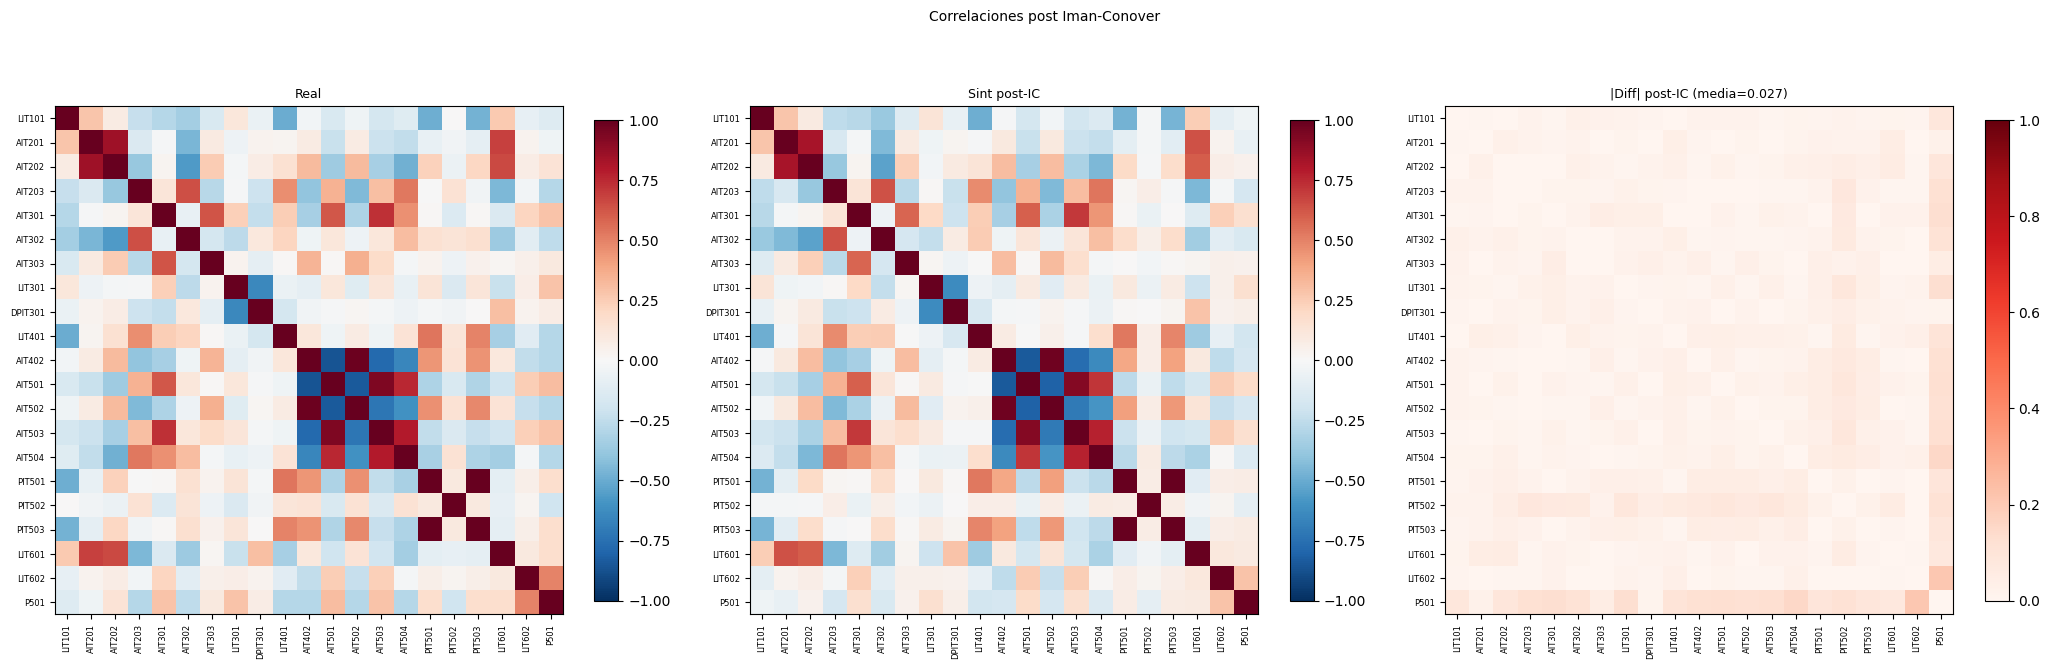

synth_qt_corrected actualizado con Iman-Conover.


In [25]:
from scipy.stats import rankdata as sp_rankdata

print("=== IMAN-CONOVER CORRELATION REMAPPING (Fix D5) ===")
print()

N_ic, T_ic, F_ic = synth_qt_corrected.shape

# Medias por ventana: (N, F) — valor representativo de cada ventana por sensor
synth_wmean = synth_qt_corrected.mean(axis=1)   # (N_synth, F)
real_wmean  = train_windows.mean(axis=1)         # (N_real, F)

# Correlacion real de medias de ventana
C_real_ic = np.corrcoef(real_wmean.T)            # (F, F)
C_real_ic = (C_real_ic + C_real_ic.T) / 2       # simetrizar numericamente

# Hacer positivo definida (jitter si hace falta)
jitter = 1e-6
for _ in range(10):
    try:
        L_ic = np.linalg.cholesky(C_real_ic + jitter * np.eye(F_ic))
        break
    except np.linalg.LinAlgError:
        jitter *= 10

# Generar normales correlacionados (uno por ventana sintetica)
rng_ic  = np.random.default_rng(42)
Z_ic    = rng_ic.standard_normal((N_ic, F_ic))
Z_corr  = Z_ic @ L_ic.T     # (N_ic, F_ic) con estructura C_real_ic

# Iman-Conover: para cada sensor j, rearreglar ventanas segun rango de Z_corr[:,j]
# Preserva: forma temporal intra-ventana, distribucion marginal
# Impone: estructura de correlacion cruzada entre sensores
synth_qt_ic = np.zeros_like(synth_qt_corrected)
for j in range(F_ic):
    # Rango objetivo: posicion que cada ventana deberia ocupar para sensor j
    target_rank   = sp_rankdata(Z_corr[:, j], method="ordinal").astype(int) - 1
    # Ventanas ordenadas por su media actual para sensor j (de menor a mayor)
    order_current = np.argsort(synth_wmean[:, j])
    # Ventana fuente para cada posicion: la de rango target en el orden actual
    source_windows = order_current[target_rank]
    synth_qt_ic[:, :, j] = synth_qt_corrected[source_windows, :, j]

# Verificacion de correlaciones antes y despues
synth_wmean_after = synth_qt_ic.mean(axis=1)
C_synth_before = np.corrcoef(synth_wmean.T)
C_synth_after  = np.corrcoef(synth_wmean_after.T)
diff_before = np.abs(C_real_ic - C_synth_before).mean()
diff_after  = np.abs(C_real_ic - C_synth_after ).mean()

print(f"Diff media correlaciones: antes={diff_before:.4f}  ->  despues={diff_after:.4f}")
print(f"Mejora: {100*(diff_before-diff_after)/max(diff_before,1e-10):.1f}%")
print()

# Verificar que marginales se preservaron
_rf   = train_windows.reshape(-1, F_ic)
_before = synth_qt_corrected.reshape(-1, F_ic)
_after  = synth_qt_ic.reshape(-1, F_ic)
dm_before_ic = np.abs(_rf.mean(0) - _before.mean(0)).mean()
dm_after_ic  = np.abs(_rf.mean(0) - _after.mean(0) ).mean()
print(f"diff_medias global: antes={dm_before_ic:.4f}  despues={dm_after_ic:.4f}")
print(f"(las marginales deben preservarse: diff_medias similar antes y despues)")
print()

# Heatmap de correlaciones despues del remapping
labs_ic = [s.replace(".Pv","").replace("P501.Speed","P501") for s in GAN_CONT_COLS]
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, data, title in zip(axes,
    [C_real_ic, C_synth_after, np.abs(C_real_ic - C_synth_after)],
    ["Real", "Sint post-IC", f"|Diff| post-IC (media={diff_after:.3f})"]):
    vmin, vmax = (-1, 1) if "Diff" not in title else (0, 1)
    cmap = "RdBu_r" if "Diff" not in title else "Reds"
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(F_ic)); ax.set_xticklabels(labs_ic, rotation=90, fontsize=6)
    ax.set_yticks(range(F_ic)); ax.set_yticklabels(labs_ic, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.suptitle("Correlaciones post Iman-Conover", fontsize=10)
plt.tight_layout(); plt.show()

# Aplicar: synth_qt_corrected ahora incluye el remapping
synth_qt_corrected = synth_qt_ic
print("synth_qt_corrected actualizado con Iman-Conover.")


## D5. Diagnóstico Post-QM — Matriz de Correlación Cruzada

Las correlaciones entre sensores reflejan las relaciones físicas del sistema SWaT.
Si la matriz sintética difiere mucho de la real, los datos no capturan la
causalidad física del sistema (e.g., cuando LIT101 baja, FIT201 sube).

Una diferencia alta en correlaciones explica por qué el t-SNE puede estar
separado incluso cuando las marginales individuales son perfectas.


=== D5: MATRIZ DE CORRELACION CRUZADA REAL vs SINTETICO ===



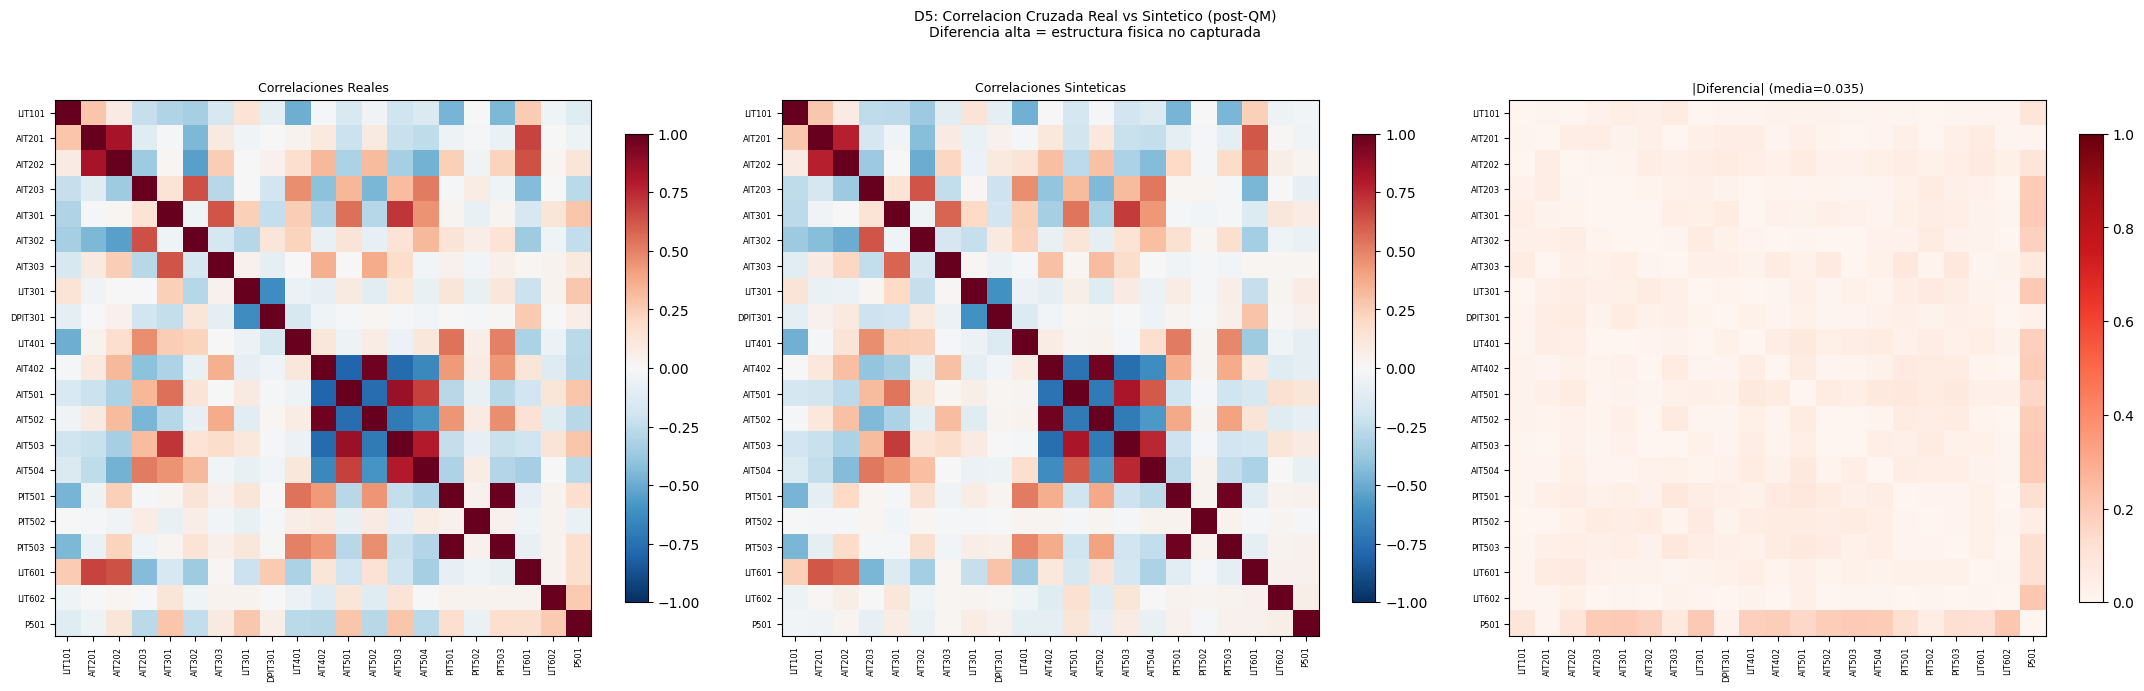

Diferencia media de correlaciones: 0.0354  (ideal: < 0.10)
Diferencia maxima:                 0.2087

Top 5 pares con mayor diferencia de correlacion:
  LIT602.Pv            vs P501.Speed          : real=+0.265  sint=+0.057  |diff|=0.209
  LIT301.Pv            vs P501.Speed          : real=+0.271  sint=+0.071  |diff|=0.200
  AIT301.Pv            vs P501.Speed          : real=+0.274  sint=+0.075  |diff|=0.199
  AIT503.Pv            vs P501.Speed          : real=+0.277  sint=+0.079  |diff|=0.197
  AIT504.Pv            vs P501.Speed          : real=-0.268  sint=-0.074  |diff|=0.194


In [26]:
print("=== D5: MATRIZ DE CORRELACION CRUZADA REAL vs SINTETICO ===")
print()

n_cc = min(2000, len(train_windows))
rng_cc = np.random.default_rng(99)
idx_cc = rng_cc.choice(len(train_windows), n_cc, replace=False)

real_cc  = train_windows[idx_cc].reshape(-1, len(GAN_CONT_COLS))
synth_cc = synth_qt_corrected[idx_cc].reshape(-1, len(GAN_CONT_COLS))

corr_r = np.corrcoef(real_cc.T)
corr_s = np.corrcoef(synth_cc.T)
corr_d = np.abs(corr_r - corr_s)

labs = [s.replace(".Pv","").replace("P501.Speed","P501") for s in GAN_CONT_COLS]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, data, title in zip(axes,
    [corr_r, corr_s, corr_d],
    ["Correlaciones Reales", "Correlaciones Sinteticas",
     f"|Diferencia| (media={corr_d.mean():.3f})"]):
    vmin, vmax = (-1, 1) if "Diferencia" not in title else (0, 1)
    cmap = "RdBu_r" if "Diferencia" not in title else "Reds"
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, rotation=90, fontsize=6)
    ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=6)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.suptitle("D5: Correlacion Cruzada Real vs Sintetico (post-QM)\n"
             "Diferencia alta = estructura fisica no capturada", fontsize=10)
plt.tight_layout(); plt.show()

print(f"Diferencia media de correlaciones: {corr_d.mean():.4f}  (ideal: < 0.10)")
print(f"Diferencia maxima:                 {corr_d.max():.4f}")
print()
# Top 5 pares mas diferentes
mask = np.triu(np.ones_like(corr_d, dtype=bool), k=1)
pairs = [(corr_d[i,j], i, j) for i in range(len(GAN_CONT_COLS))
         for j in range(i+1, len(GAN_CONT_COLS))]
pairs_sorted = sorted(pairs, reverse=True)[:5]
print("Top 5 pares con mayor diferencia de correlacion:")
for diff, i, j in pairs_sorted:
    print(f"  {GAN_CONT_COLS[i]:<20} vs {GAN_CONT_COLS[j]:<20}: "
          f"real={corr_r[i,j]:+.3f}  sint={corr_s[i,j]:+.3f}  |diff|={diff:.3f}")


## 13c. Detrending — eliminado en v12

El detrending (soft o duro) fue introducido en v10-v11 para compensar el drift
intra-ventana generado por el GAN. Con el modelo de tamano correcto (hidden_dim=128,
R1_LAMBDA=0.01), el GAN deberia generar series mas estables y el detrending no
deberia ser necesario.

A7 v21 no tenia detrending y sus series temporales sintéticas eran visualmente
comparables a las reales.

Si v12 muestra drift residual significativo en las series temporales (visible en
la grafica comparative_timeseries.png), se puede re-introducir el detrending soft
en v13 partiendo de una base ya estable.


In [27]:
# v12: sin detrending. synth_qt_corrected ya esta listo tras el QM.
# El detrending se eliminó porque A7 v21 no lo necesitaba con hidden_dim=128.
# Si se observa drift residual significativo en las series temporales,
# se puede re-introducir en v13.

SLOW_SENSORS_QT = [s for s in GAN_CONT_COLS
                   if s.startswith('LIT') or s.startswith('AIT')
                   or s.startswith('PIT')]

# Verificacion de std intra-ventana (solo diagnostico, sin modificar datos)
print("=== VERIFICACION STD INTRA-VENTANA (solo diagnostico, sin intervencion) ===")
print(f'{"Sensor":<20}  {"real_intra_std":>14}  {"synth_intra_std":>16}  {"ratio":>8}')
print('-' * 66)
for s in SLOW_SENSORS_QT:
    j = GAN_CONT_COLS.index(s)
    real_std  = float(train_windows[:, :, j].std(axis=1).mean())
    synth_std = float(synth_qt_corrected[:, :, j].std(axis=1).mean())
    ratio     = synth_std / max(real_std, 1e-8)
    flag      = "  <- DRIFT ALTO" if ratio > 3.0 else ""
    print(f'{s:<20}  {real_std:>14.5f}  {synth_std:>16.5f}  {ratio:>8.3f}{flag}')
print()
print("Si ratio > 3.0 en muchos sensores, considerar re-introducir detrending en v13.")


=== VERIFICACION STD INTRA-VENTANA (solo diagnostico, sin intervencion) ===
Sensor                real_intra_std   synth_intra_std     ratio
------------------------------------------------------------------
LIT101.Pv                    0.02023           0.03264     1.613
AIT201.Pv                    0.01590           0.02647     1.665
AIT202.Pv                    0.05855           0.06396     1.092
AIT203.Pv                    0.01088           0.02428     2.231
AIT301.Pv                    0.01882           0.02285     1.214
AIT302.Pv                    0.00851           0.02236     2.626
AIT303.Pv                    0.01000           0.02266     2.267
LIT301.Pv                    0.02025           0.04727     2.334
LIT401.Pv                    0.01302           0.02612     2.006
AIT402.Pv                    0.00944           0.01829     1.938
AIT501.Pv                    0.09880           0.10395     1.052
AIT502.Pv                    0.02090           0.02367     1.132
AIT503.Pv   

## D6. Diagnóstico Temporal — Autocorrelación Intra-Ventana

Este diagnóstico responde: **¿las ventanas sintéticas tienen la estructura temporal correcta?**

La autocorrelación a lag=1 (ACF1) mide cuánto se parece un valor al inmediatamente anterior.
Los sensores reales lentos tienen ACF1 ≈ 1.0 (casi no cambian en 1 segundo).
Si los sintéticos tienen ACF1 mucho menor, el GAN genera ruido en lugar de continuidad.


=== D6: DIAGNOSTICO TEMPORAL — AUTOCORRELACION INTRA-VENTANA ===

Sensor                 ACF1_real   ACF1_sint      diff  Estado
------------------------------------------------------------
LIT101.Pv                 0.9998      0.9993    0.0004  OK
AIT201.Pv                 0.9993      0.9990    0.0003  OK
AIT202.Pv                 0.9990      0.9950    0.0040  OK
AIT203.Pv                 0.9996      0.9986    0.0010  OK
AIT301.Pv                 0.9996      0.9994    0.0002  OK
AIT302.Pv                 1.0000      0.9993    0.0007  OK
AIT303.Pv                 0.9995      0.9994    0.0001  OK
LIT301.Pv                 0.9997      0.9980    0.0017  OK
DPIT301.Pv                0.9906      0.9927    0.0021  OK
LIT401.Pv                 1.0000      0.9992    0.0008  OK
AIT402.Pv                 0.9996      0.9996    0.0000  OK
AIT501.Pv                 0.9978      0.9937    0.0042  OK
AIT502.Pv                 0.9989      0.9995    0.0006  OK
AIT503.Pv                 0.9998      0.999

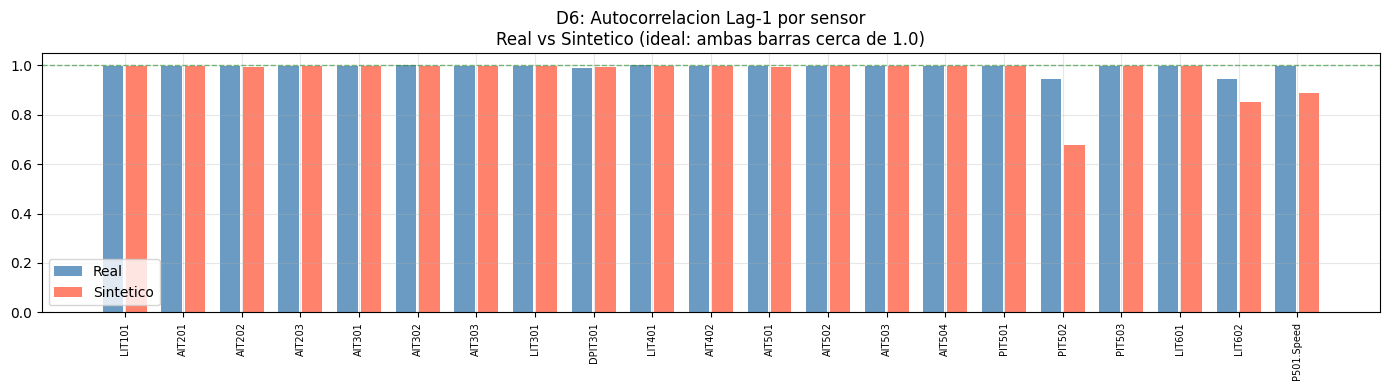

In [28]:
print("=== D6: DIAGNOSTICO TEMPORAL — AUTOCORRELACION INTRA-VENTANA ===")
print()

def acf1(windows_3d):  # (N, T, feat) -> (feat,)
    x = windows_3d  # (N, T, F)
    lag0 = x[:, :-1, :]  # (N, T-1, F)
    lag1 = x[:, 1:,  :]  # (N, T-1, F)
    acf  = np.array([
        np.corrcoef(lag0[:,:,j].flatten(), lag1[:,:,j].flatten())[0,1]
        for j in range(x.shape[2])
    ])
    return acf

acf_r = acf1(train_windows)
acf_s = acf1(synth_qt_corrected)
acf_d = np.abs(acf_r - acf_s)

print(f'{"Sensor":<20}  {"ACF1_real":>10}  {"ACF1_sint":>10}  {"diff":>8}  Estado')
print("-" * 60)
for j, s in enumerate(GAN_CONT_COLS):
    est = "OK" if acf_d[j]<0.10 else ("REVISAR" if acf_d[j]<0.25 else "MAL")
    print(f'{s:<20}  {acf_r[j]:>10.4f}  {acf_s[j]:>10.4f}  {acf_d[j]:>8.4f}  {est}')
print()
print(f"ACF1 media real:  {acf_r.mean():.4f}")
print(f"ACF1 media sint:  {acf_s.mean():.4f}")
print(f"Diff media:       {acf_d.mean():.4f}  (ideal: < 0.05)")
print()

# Grafica
fig, ax = plt.subplots(figsize=(14, 4))
x_pos = np.arange(len(GAN_CONT_COLS))
ax.bar(x_pos - 0.2, acf_r, 0.35, color="steelblue", alpha=0.8, label="Real")
ax.bar(x_pos + 0.2, acf_s, 0.35, color="tomato",    alpha=0.8, label="Sintetico")
ax.set_xticks(x_pos)
ax.set_xticklabels([s.replace(".Pv","") for s in GAN_CONT_COLS], rotation=90, fontsize=7)
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="green",  linestyle="--", lw=1.0, alpha=0.5)
ax.set_title("D6: Autocorrelacion Lag-1 por sensor\n"
             "Real vs Sintetico (ideal: ambas barras cerca de 1.0)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


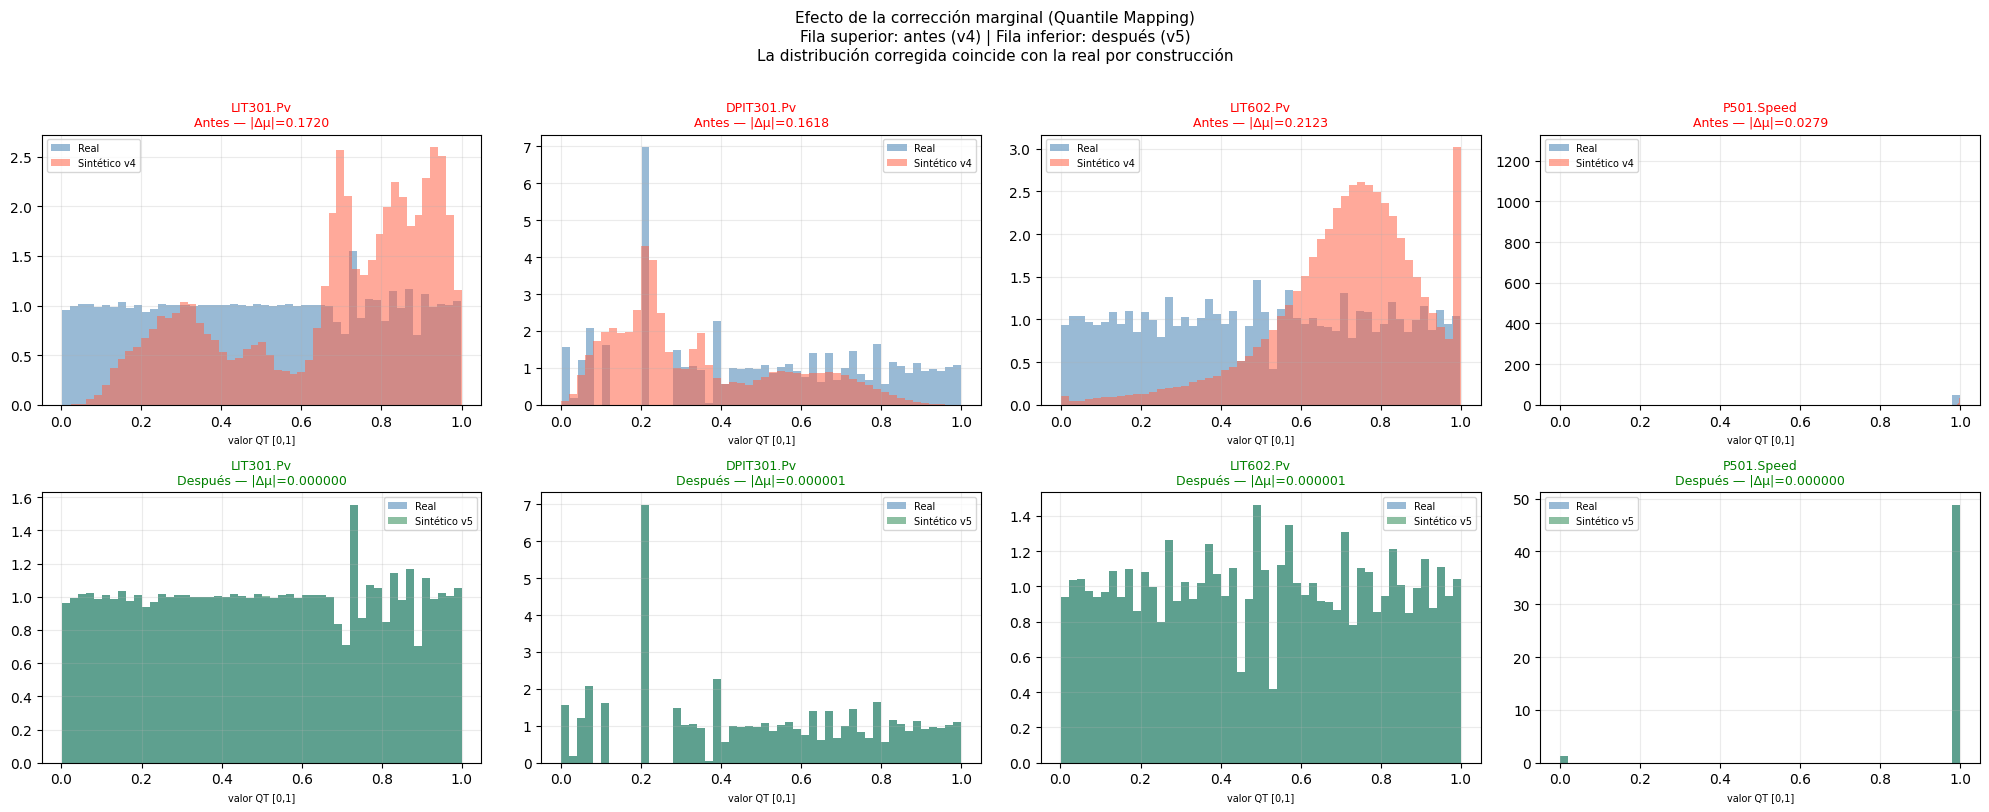

Guardado: correction_before_after.png


In [29]:
# Verificación visual: histogramas antes y después de la corrección
fig, axes = plt.subplots(2, len(CORRECTION_SENSORS), figsize=(5*len(CORRECTION_SENSORS), 8))

for j_plot, sensor in enumerate(CORRECTION_SENSORS):
    j = GAN_CONT_COLS.index(sensor)
    real_vals   = train_windows[:, :, j].flatten()
    synth_orig  = synth_qt_clipped[:, :, j].flatten()
    synth_corr  = synth_qt_corrected[:, :, j].flatten()

    # Panel superior: antes de la corrección
    ax1 = axes[0, j_plot]
    ax1.hist(real_vals,  bins=50, alpha=0.55, color='steelblue', density=True, label='Real')
    ax1.hist(synth_orig, bins=50, alpha=0.55, color='tomato',    density=True, label='Sintético v4')
    dm = abs(real_vals.mean() - synth_orig.mean())
    ax1.set_title(f'{sensor}\nAntes — |Δμ|={dm:.4f}', fontsize=9, color='red')
    ax1.legend(fontsize=7); ax1.grid(True, alpha=0.25)
    ax1.set_xlabel('valor QT [0,1]', fontsize=7)

    # Panel inferior: después de la corrección
    ax2 = axes[1, j_plot]
    ax2.hist(real_vals,  bins=50, alpha=0.55, color='steelblue', density=True, label='Real')
    ax2.hist(synth_corr, bins=50, alpha=0.55, color='seagreen',  density=True, label='Sintético v5')
    dm_c = abs(real_vals.mean() - synth_corr.mean())
    ax2.set_title(f'{sensor}\nDespués — |Δμ|={dm_c:.6f}', fontsize=9, color='green')
    ax2.legend(fontsize=7); ax2.grid(True, alpha=0.25)
    ax2.set_xlabel('valor QT [0,1]', fontsize=7)

fig.suptitle(
    'Efecto de la corrección marginal (Quantile Mapping)\n'
    'Fila superior: antes (v4) | Fila inferior: después (v5)\n'
    'La distribución corregida coincide con la real por construcción',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / 'correction_before_after.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: correction_before_after.png')


In [30]:
# Inverse transform → escala física
n_gan = len(GAN_CONT_COLS)
# v5: usar synth_qt_corrected (con corrección marginal) en lugar de synth_qt_clipped
synth_qt_flat  = synth_qt_corrected.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    """Síntesis empírica condicional para sensores de flujo bimodales."""

    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97:
                    state = 0 if rng.random() < p0 else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows

def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    """Síntesis empírica con persistencia para variables discretas."""

    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp = disc_empirical[col]
        vals = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = windows[i,t-1,j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_BIMODAL_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

# Verificar bimodalidad FITs
print("Verificación P(0) FITs sintetizados:")
for j, col in enumerate(FIT_BIMODAL_COLS):
    p0_real  = fit_empirical[col]["p_zero"]
    p0_synth = (synth_fit_raw[:,:,j] == 0.0).mean()
    ok = "✅" if abs(p0_real - p0_synth) < 0.02 else "⚠️ "
    print(f"  {ok} {col}: real={p0_real:.3f}, sint={p0_synth:.3f}")


Verificación P(0) FITs sintetizados:
  ✅ FIT101.Pv: real=0.872, sint=0.877
  ✅ FIT201.Pv: real=0.573, sint=0.565
  ✅ FIT301.Pv: real=0.330, sint=0.342
  ✅ FIT401.Pv: real=0.022, sint=0.021
  ✅ FIT501.Pv: real=0.000, sint=0.000
  ✅ FIT502.Pv: real=0.000, sint=0.000
  ✅ FIT503.Pv: real=0.000, sint=0.000
  ✅ FIT504.Pv: real=0.022, sint=0.023
  ✅ FIT601.Pv: real=1.000, sint=1.000
  ✅ FIT602.Pv: real=0.000, sint=0.000


In [31]:
# Construir array completo de continuas en orden del detector
synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]
for j, col in enumerate(FIT_BIMODAL_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

# Escalar con scaler_cont del detector para compatibilidad con 01b
synth_for_det = scaler_cont.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("Shapes de datos sintéticos:")
print(f"  synth_qt_clipped: {synth_qt_clipped.shape}   (espacio QT)")
print(f"  synth_gan_phys:   {synth_gan_phys.shape}     (escala física GAN)")
print(f"  synth_fit_raw:    {synth_fit_raw.shape}     (escala física FIT)")
print(f"  synth_for_det:    {synth_for_det.shape}     (escalado detector)")


Shapes de datos sintéticos:
  synth_qt_clipped: (3063, 60, 21)   (espacio QT)
  synth_gan_phys:   (3063, 60, 21)     (escala física GAN)
  synth_fit_raw:    (3063, 60, 10)     (escala física FIT)
  synth_for_det:    (3063, 60, 31)     (escalado detector)


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [32]:
def summarize_disc(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print(f"X_synth_cont (para detector): {X_synth_cont.shape}")
print(f"X_synth_disc (para detector): {X_synth_disc.shape}")


X_synth_cont (para detector): (3063, 31, 60)
X_synth_disc (para detector): (3063, 124)


## 14. Evaluación de calidad distribucional: PCA y t-SNE

### Métricas de evaluación

**Diff medias QT (0.042):** diferencia media absoluta entre los valores escalados
de las ventanas reales vs sintéticas en el espacio QT. Valor 0.042 sobre un rango
[0,1] → 4.2% de diferencia → ✅ excelente para datos industriales.

**Diff medias PCA (0.106):** diferencia en el espacio PCA de las ventanas aplanadas
(30×27=810 dimensiones). Valor 0.106 indica que los centroides de las nubes de puntos
real y sintética están a 10.6% de separación en el espacio PCA.

**Sobre el AUC=1.0 del RandomForest:** con 810 dimensiones aplanadas, el RF siempre
puede encontrar diferencias. La importancia máxima de feature es la señal relevante:
0.074 en AIT502.Pv (timestep 2) y 0.068 en LIT101.Pv (timestep 21). Estas features
son precisamente las que muestran drift temporal intra-sesión.

### Interpretación del t-SNE y la diff medias PCA

Las distribuciones no se solapan perfectamente en PCA/t-SNE. Esto no indica
un fallo del GAN — es consecuencia del **drift temporal intra-sesión**:

- El train cubre 09:02–13:00 (primeras 4h de la sesión)
- Los datos que compara el PCA incluyen ventanas de val/test (13:00–17:00)
- El sistema SWaT evoluciona durante el día: LIT101 (nivel del tanque 1)
  tiene valores distintos a mediodía que a las 17:00
- El GAN aprende la distribución de la mañana → genera datos "de mañana"

La diferencia PCA mide parcialmente el drift del sistema, no solo la calidad del GAN.
La **métrica definitiva** de calidad es el TSTR (Train on Synthetic, Test on Real)
en la validación interna y externa — notebooks 05 y 07.


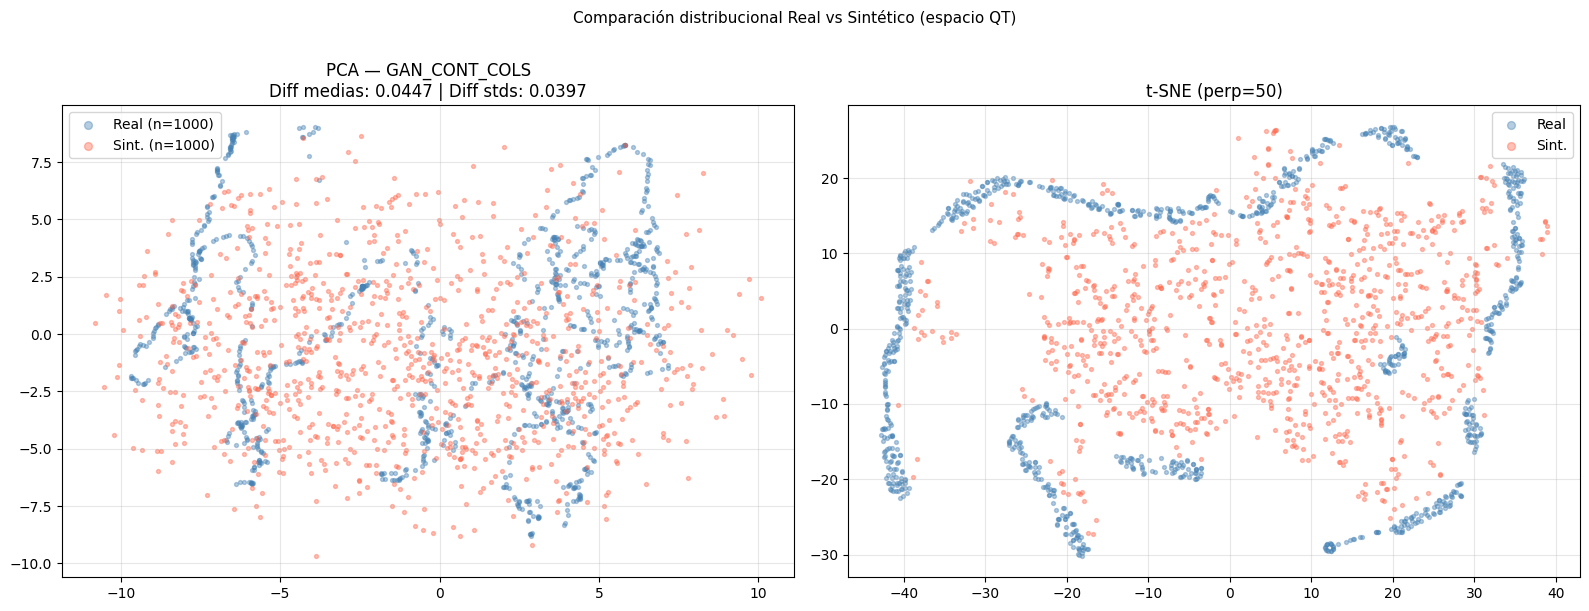

Diff medias: 0.0447  ✅
Diff stds:   0.0397  ✅


In [33]:
n_plot  = min(1000, len(train_windows), n_synth)
rng     = np.random.default_rng(SEED)
ri      = rng.choice(len(train_windows),  n_plot, replace=False)
si      = rng.choice(n_synth,             n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
# v5: evaluar con la versión corregida
synth_s = synth_qt_corrected[si].reshape(n_plot, -1)

md_diff = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd_diff = np.abs(real_s.std(0)  - synth_s.std(0)).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pca_v = PCA(n_components=2, random_state=SEED)
pr = pca_v.fit_transform(real_s); ps = pca_v.transform(synth_s)
axes[0].scatter(pr[:,0], pr[:,1], alpha=0.4, c="steelblue", s=8, label=f"Real (n={n_plot})")
axes[0].scatter(ps[:,0], ps[:,1], alpha=0.4, c="tomato",    s=8, label=f"Sint. (n={n_plot})")
axes[0].set_title(f"PCA — GAN_CONT_COLS\nDiff medias: {md_diff:.4f} | Diff stds: {sd_diff:.4f}")
axes[0].legend(markerscale=2); axes[0].grid(True, alpha=0.3)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s]))
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot,0], tout[:n_plot,1], alpha=0.4, c="steelblue", s=8, label="Real")
axes[1].scatter(tout[n_plot:,0], tout[n_plot:,1], alpha=0.4, c="tomato",    s=8, label="Sint.")
axes[1].set_title(f"t-SNE (perp={perp})"); axes[1].legend(markerscale=2); axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparación distribucional Real vs Sintético (espacio QT)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / "tsne_pca.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Diff medias: {md_diff:.4f}  {'✅' if md_diff<0.10 else '⚠️'}")
print(f"Diff stds:   {sd_diff:.4f}  {'✅' if sd_diff<0.10 else '⚠️'}")


## 14b. Comparativas sensor por sensor: Real vs Sintético

Esta sección compara directamente las distribuciones y series temporales de cada
feature entre datos reales (entrenamiento) y datos sintéticos generados.

**Cómo interpretar las gráficas:**
- **Histogramas superpuestos:** comparan la distribución marginal (ignorando el tiempo).
  Solapamiento alto → el GAN reprodujo bien la distribución estática de ese sensor.
- **Series temporales de muestra:** comparan la evolución en el tiempo dentro de
  una ventana de 30 segundos. Patrones similares → el GAN aprendió la dinámica temporal.
- **FITs bimodales:** verifican que la proporción 0/open se preserva y que los
  valores de flujo abierto tienen la distribución correcta.


C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\3369270757.py:45: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\3369270757.py:45: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\3369270757.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(str(TIMEGAN_DIR / 'comparative_histograms_qt.png'), dpi=120, bbox_inches='tight')
C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\3369270757.py:46: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(str(TIMEGAN_DIR / 'comparative_histograms_qt.png'), dpi=120, bbox_inches='tight')
d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MAR

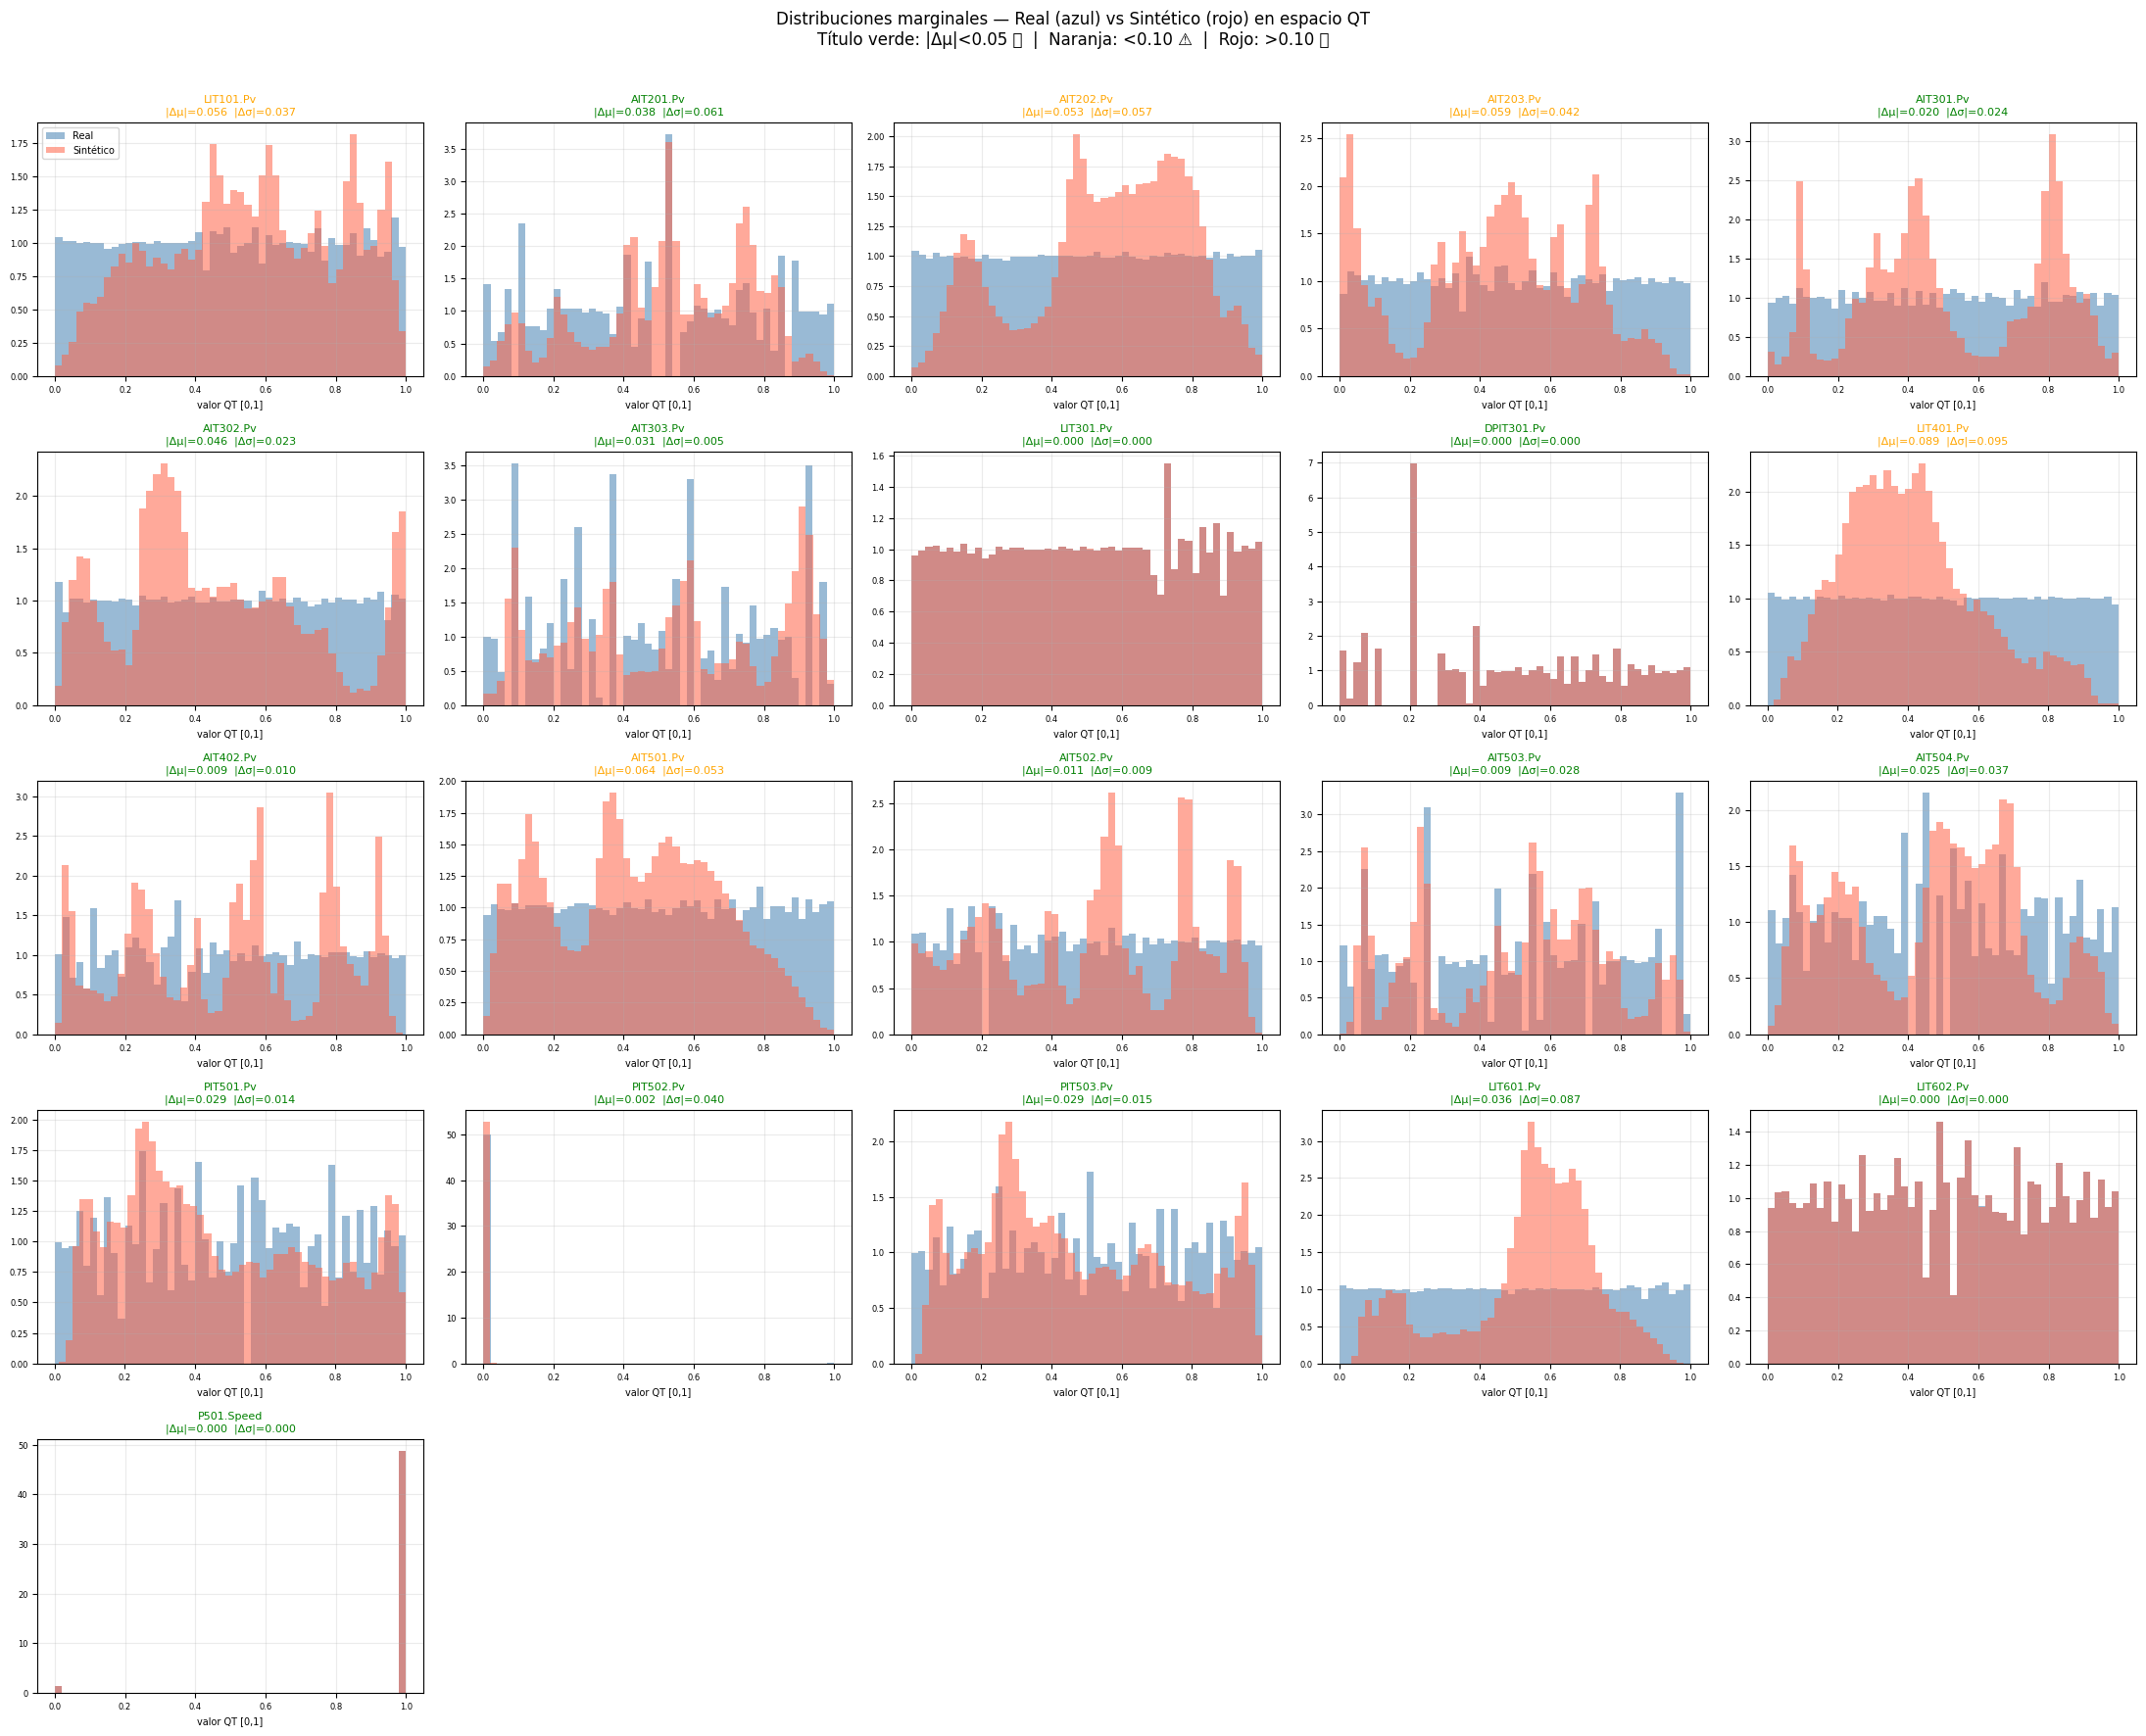

Guardado: comparative_histograms_qt.png


In [34]:
# ─── Comparativa de distribuciones marginales (histogramas) ──────────────────
# Real: train_windows (escala QT, shape N×30×27)
# Sintético: synth_qt_clipped (escala QT, misma shape)

# Aplanar dimensión temporal para comparar distribuciones marginales
real_flat  = train_windows.reshape(-1, len(GAN_CONT_COLS))   # (N*30, 27)
# v5: comparar con la versión corregida
synth_flat = synth_qt_corrected.reshape(-1, len(GAN_CONT_COLS)) # (N*30, 27)

n_features = len(GAN_CONT_COLS)
ncols = 5
nrows = math.ceil(n_features / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 3.5*nrows))
axes = axes.flatten()

for j, col in enumerate(GAN_CONT_COLS):
    ax = axes[j]
    ax.hist(real_flat[:, j],  bins=50, alpha=0.55, color='steelblue', density=True,
            label='Real', edgecolor='none')
    ax.hist(synth_flat[:, j], bins=50, alpha=0.55, color='tomato',    density=True,
            label='Sintético', edgecolor='none')

    # Diferencia de medias y stds como indicador de calidad
    dm = abs(real_flat[:,j].mean() - synth_flat[:,j].mean())
    ds = abs(real_flat[:,j].std()  - synth_flat[:,j].std())
    color_title = 'green' if dm < 0.05 else ('orange' if dm < 0.10 else 'red')

    ax.set_title(f'{col}\n|Δμ|={dm:.3f}  |Δσ|={ds:.3f}', fontsize=8,
                 color=color_title)
    ax.set_xlabel('valor QT [0,1]', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.25)
    if j == 0:
        ax.legend(fontsize=7)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Distribuciones marginales — Real (azul) vs Sintético (rojo) en espacio QT\n'
    'Título verde: |Δμ|<0.05 ✅  |  Naranja: <0.10 ⚠️  |  Rojo: >0.10 ❌',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / 'comparative_histograms_qt.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: comparative_histograms_qt.png')


C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\2151461649.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\2151461649.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\2151461649.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(str(TIMEGAN_DIR / 'comparative_histograms_physical.png'), dpi=120, bbox_inches='tight')
C:\Users\Juan\AppData\Local\Temp\ipykernel_22592\2151461649.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(str(TIMEGAN_DIR / 'comparative_histograms_physical.png'), dpi=120, bbox_inches='tight')
d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEA

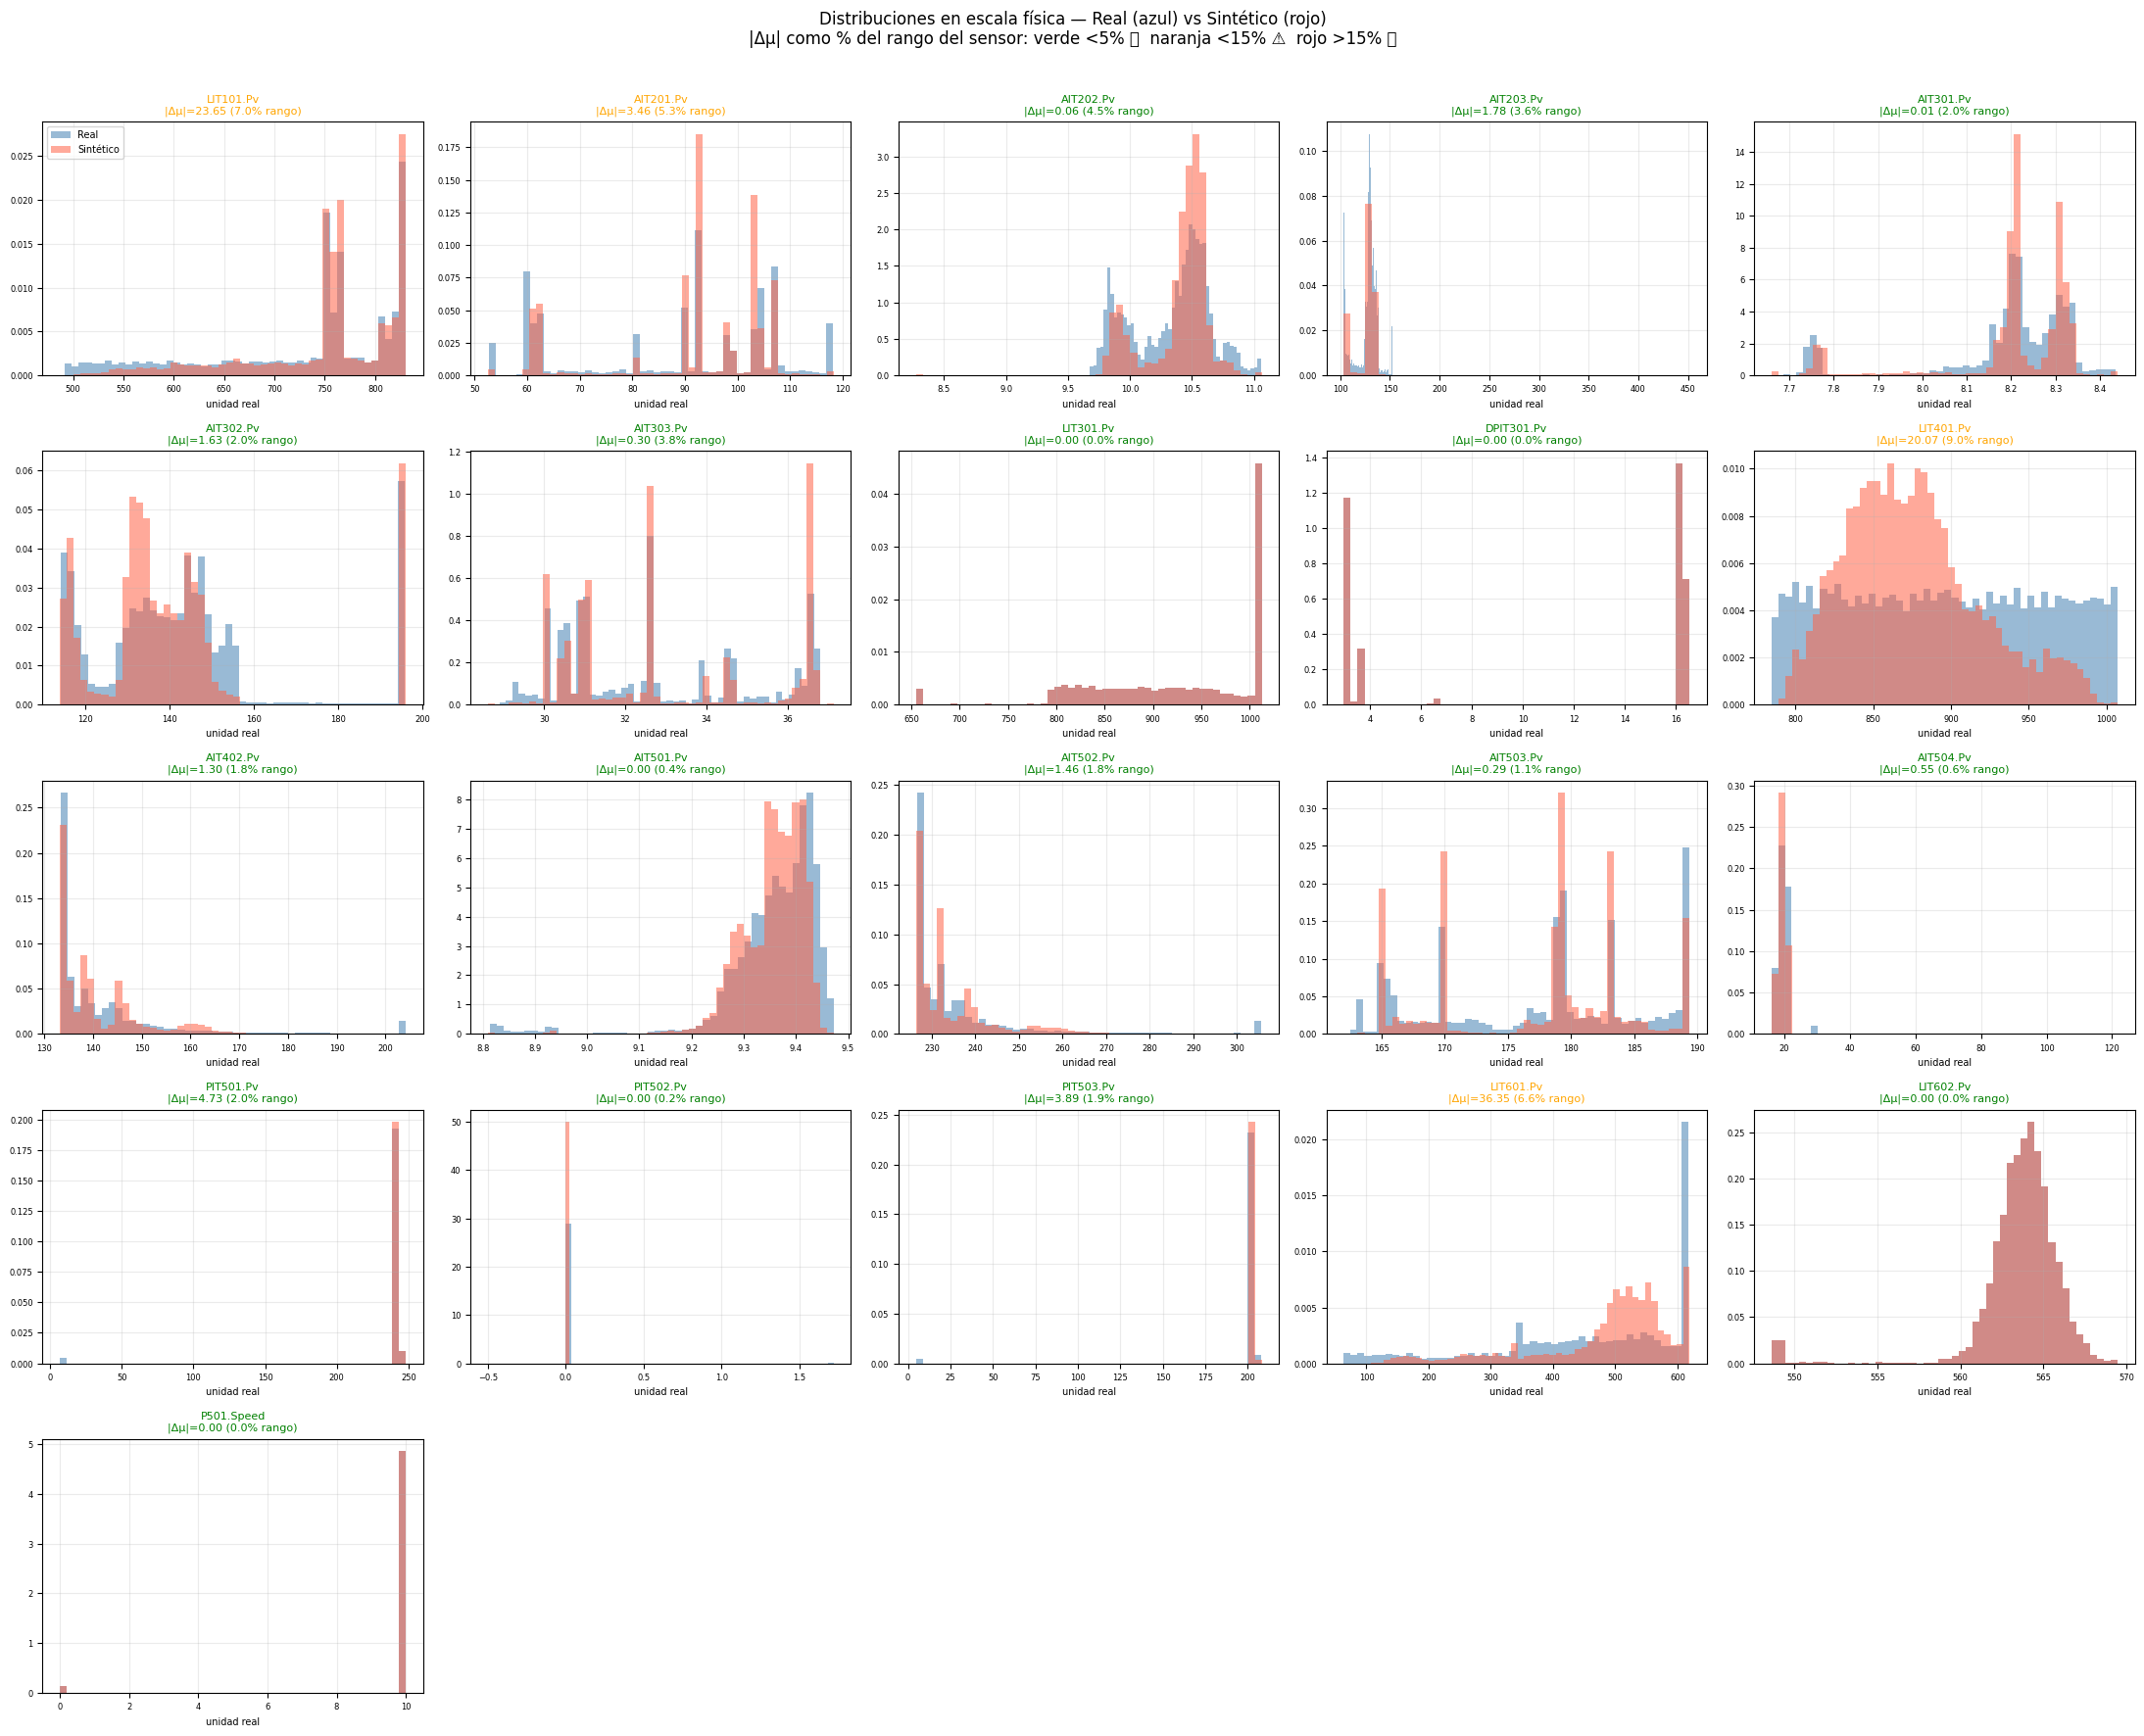

Guardado: comparative_histograms_physical.png


In [35]:
# ─── Comparativa en escala física (interpretable) ─────────────────────────────
# Inverse transform para ver las distribuciones en unidades reales del proceso

real_phys  = qt.inverse_transform(real_flat)
synth_phys = qt.inverse_transform(synth_flat)

fig, axes = plt.subplots(nrows, ncols, figsize=(22, 3.5*nrows))
axes = axes.flatten()

for j, col in enumerate(GAN_CONT_COLS):
    ax = axes[j]
    ax.hist(real_phys[:, j],  bins=50, alpha=0.55, color='steelblue', density=True,
            label='Real', edgecolor='none')
    ax.hist(synth_phys[:, j], bins=50, alpha=0.55, color='tomato',    density=True,
            label='Sintético', edgecolor='none')

    dm = abs(real_phys[:,j].mean() - synth_phys[:,j].mean())
    rng = real_phys[:,j].max() - real_phys[:,j].min() + 1e-10
    dm_pct = 100 * dm / rng
    color_title = 'green' if dm_pct < 5 else ('orange' if dm_pct < 15 else 'red')

    ax.set_title(f'{col}\n|Δμ|={dm:.2f} ({dm_pct:.1f}% rango)', fontsize=8,
                 color=color_title)
    ax.set_xlabel('unidad real', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.25)
    if j == 0:
        ax.legend(fontsize=7)

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Distribuciones en escala física — Real (azul) vs Sintético (rojo)\n'
    '|Δμ| como % del rango del sensor: verde <5% ✅  naranja <15% ⚠️  rojo >15% ❌',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / 'comparative_histograms_physical.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: comparative_histograms_physical.png')


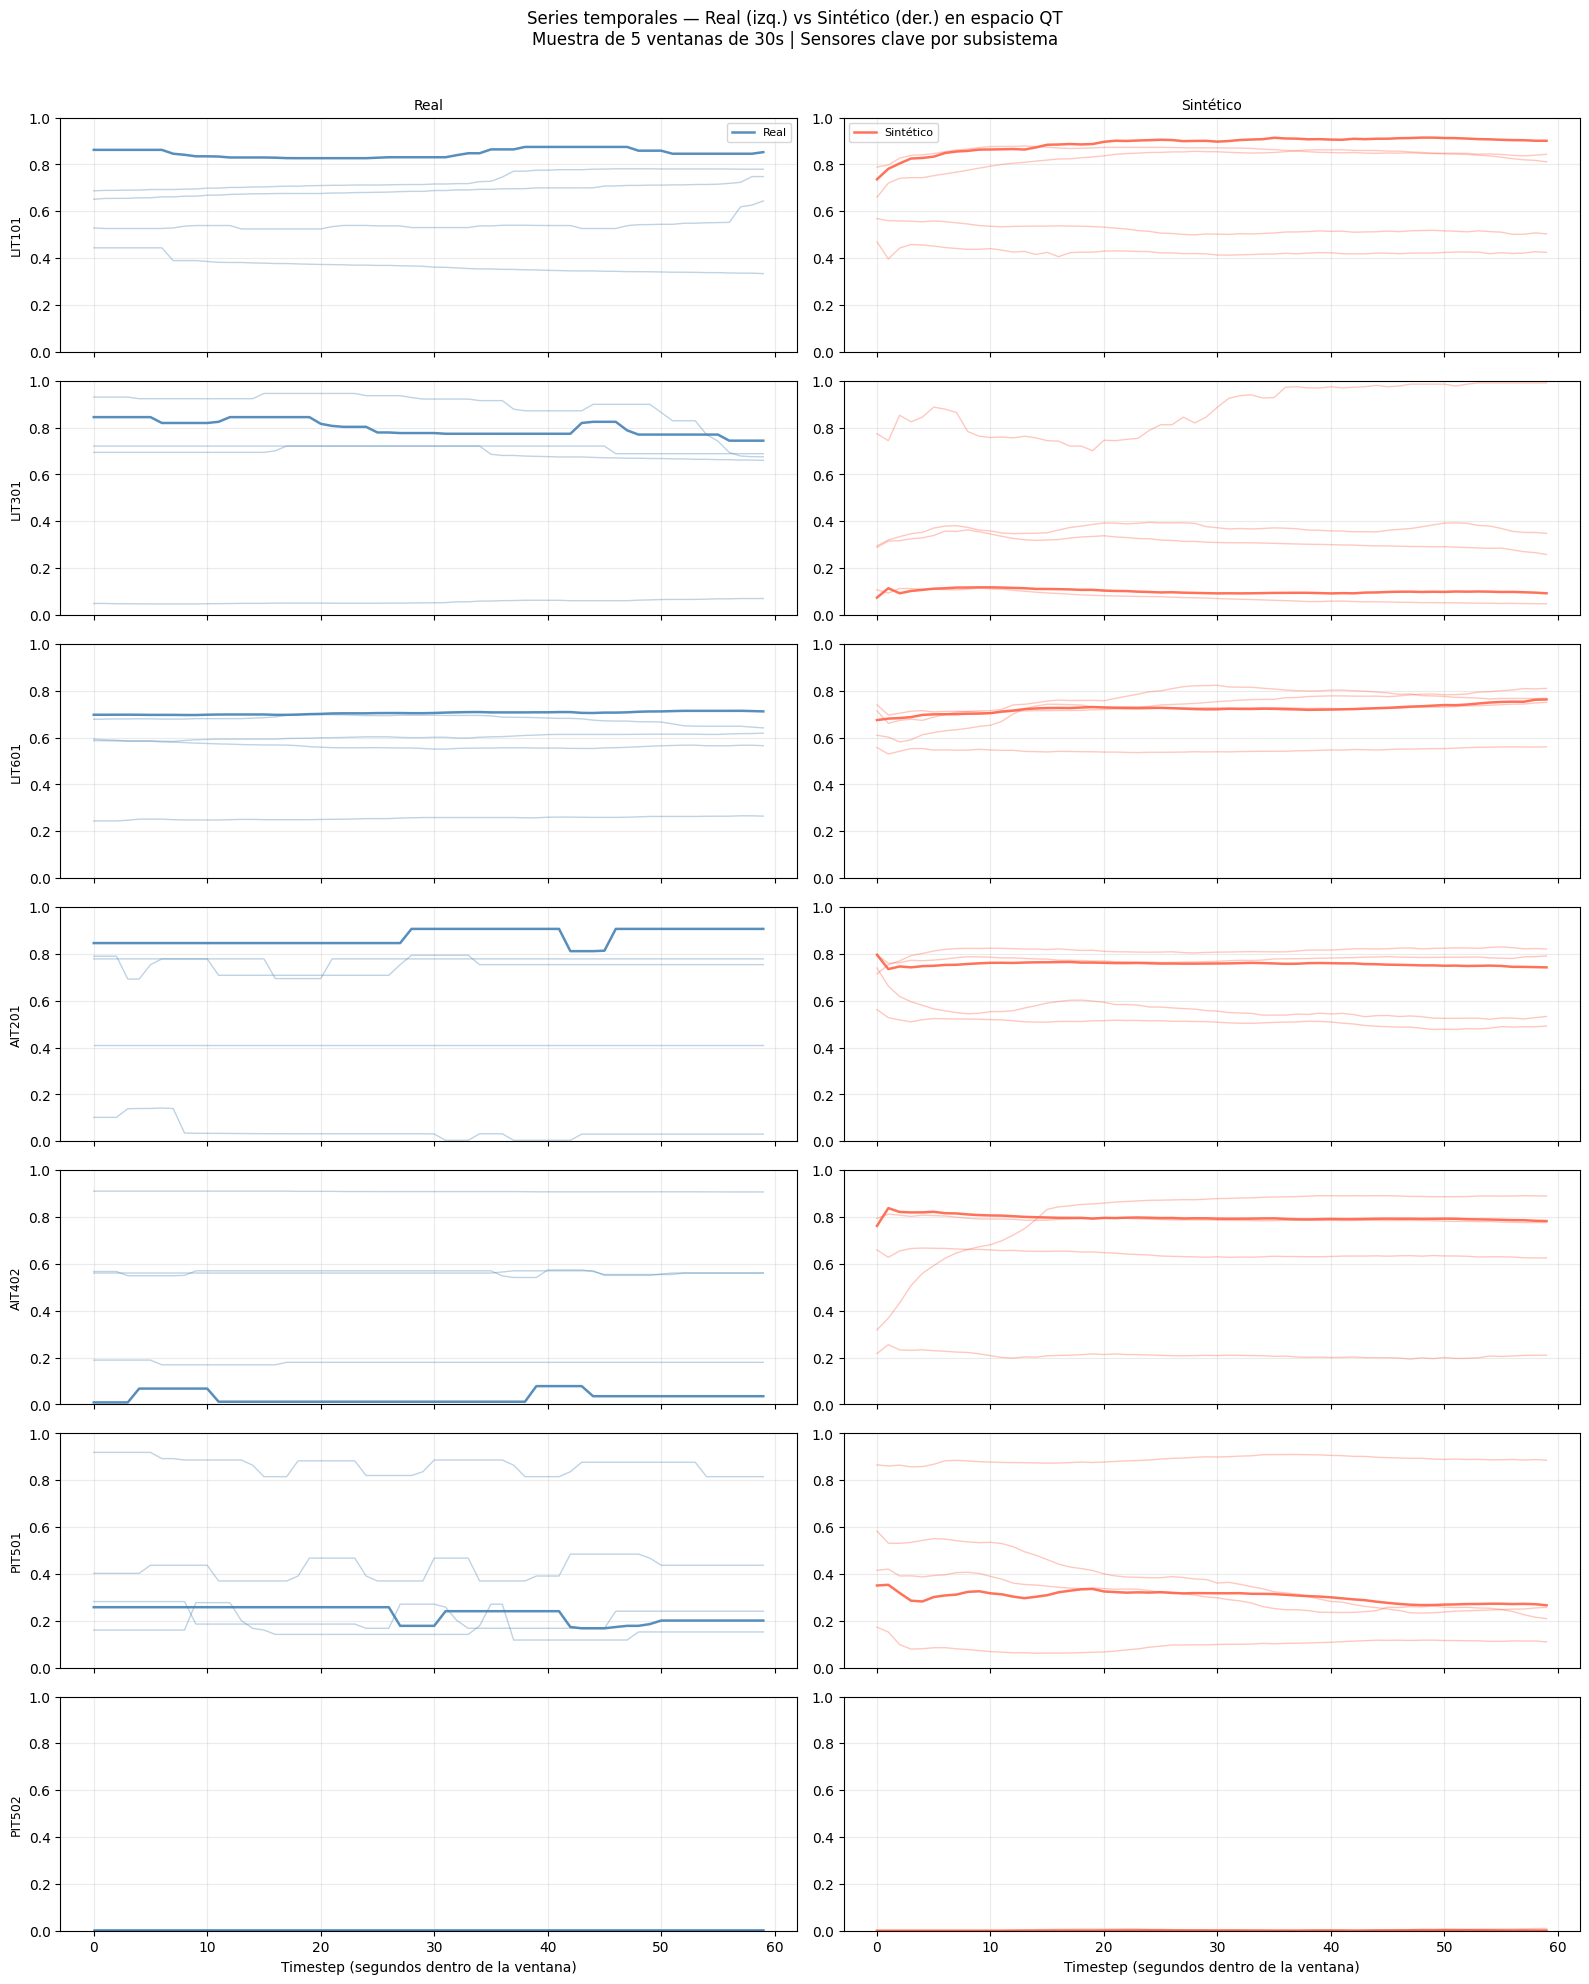

Guardado: comparative_timeseries.png


In [36]:
# ─── Series temporales: muestra de ventanas reales vs sintéticas ──────────────
# Comparar la evolución temporal para los sensores más representativos

# Sensores clave por subsistema
KEY_SENSORS = [
    'LIT101.Pv',   # Nivel tanque 1 — variable más discriminativa en RF
    'LIT301.Pv',   # Nivel tanque 3
    'LIT601.Pv',   # Nivel tanque 6
    'AIT201.Pv',   # Calidad agua etapa 2
    'AIT402.Pv',   # Calidad agua etapa 4
    'PIT501.Pv',   # Presión etapa 5
    'PIT502.Pv',   # Presión etapa 5
    'FIT501.Pv',   # Flujo etapa 5
]
KEY_SENSORS = [s for s in KEY_SENSORS if s in GAN_CONT_COLS]

N_WINDOWS = 5   # ventanas de muestra a mostrar
rng_plot = np.random.default_rng(SEED)

real_idx  = rng_plot.choice(len(train_windows), N_WINDOWS, replace=False)
synth_idx = rng_plot.choice(n_synth,            N_WINDOWS, replace=False)

fig, axes = plt.subplots(len(KEY_SENSORS), 2, figsize=(16, 2.8*len(KEY_SENSORS)),
                         sharex=True)

for row, sensor in enumerate(KEY_SENSORS):
    j = GAN_CONT_COLS.index(sensor)

    ax_r = axes[row, 0]
    ax_s = axes[row, 1]

    # Ventanas reales
    for k, wi in enumerate(real_idx):
        alpha = 0.9 if k == 0 else 0.35
        lw    = 1.8 if k == 0 else 1.0
        ax_r.plot(train_windows[wi, :, j], alpha=alpha, lw=lw,
                  color='steelblue', label='Real' if k == 0 else None)
    ax_r.set_ylabel(sensor.replace('.Pv',''), fontsize=9)
    ax_r.set_title('Real' if row == 0 else '', fontsize=10)
    ax_r.grid(True, alpha=0.25)
    if row == 0: ax_r.legend(fontsize=8)

    # Ventanas sintéticas (espacio QT para comparar en la misma escala)
    for k, wi in enumerate(synth_idx):
        alpha = 0.9 if k == 0 else 0.35
        lw    = 1.8 if k == 0 else 1.0
        ax_s.plot(synth_qt_corrected[wi, :, j], alpha=alpha, lw=lw,
                  color='tomato', label='Sintético' if k == 0 else None)
    ax_s.set_title('Sintético' if row == 0 else '', fontsize=10)
    ax_s.grid(True, alpha=0.25)
    if row == 0: ax_s.legend(fontsize=8)

    ax_r.set_ylim(0, 1); ax_s.set_ylim(0, 1)

axes[-1, 0].set_xlabel('Timestep (segundos dentro de la ventana)')
axes[-1, 1].set_xlabel('Timestep (segundos dentro de la ventana)')

fig.suptitle(
    'Series temporales — Real (izq.) vs Sintético (der.) en espacio QT\n'
    f'Muestra de {N_WINDOWS} ventanas de 30s | Sensores clave por subsistema',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / 'comparative_timeseries.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: comparative_timeseries.png')


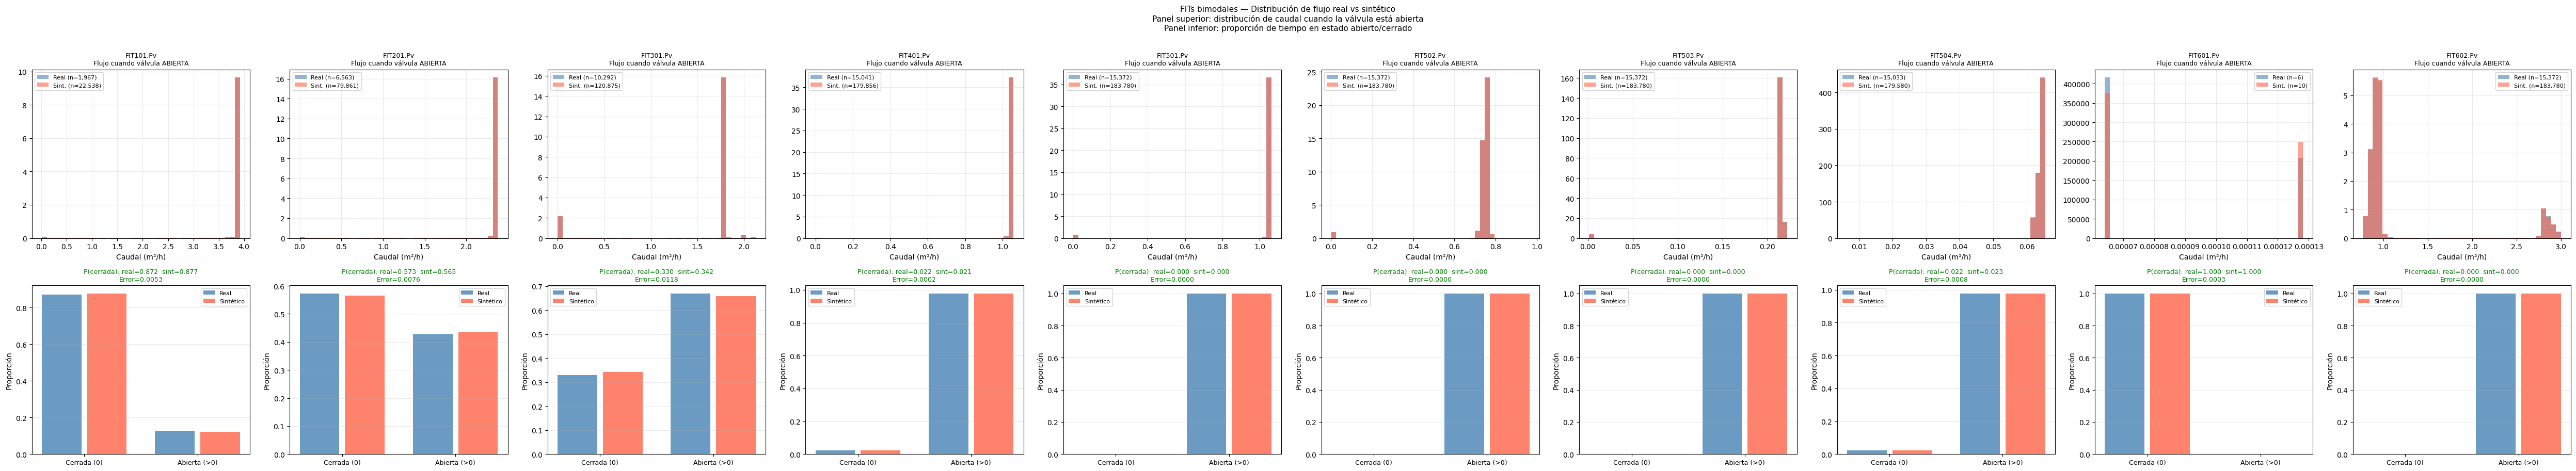

Guardado: comparative_fits_bimodal.png


In [37]:
# ─── FITs bimodales — comparativa de distribución ────────────────────────────

fig, axes = plt.subplots(2, len(FIT_BIMODAL_COLS), figsize=(5*len(FIT_BIMODAL_COLS), 9))

for j, col in enumerate(FIT_BIMODAL_COLS):
    col_idx_real = continuous_cols.index(col)

    # Datos reales del train (escala física)
    real_vals  = df_train[col].values
    synth_vals = synth_fit_raw[:, :, j].flatten()

    p0_real  = fit_empirical[col]['p_zero']
    p0_synth = (synth_vals == 0.0).mean()

    # Panel superior: distribución completa incluyendo ceros
    ax1 = axes[0, j]
    # Mostrar como barras: barra 0 (válvula cerrada) y hist del flujo abierto
    open_real  = real_vals[real_vals > 0]
    open_synth = synth_vals[synth_vals > 0]

    # Normalizar para comparar
    if len(open_real) > 0:
        ax1.hist(open_real,  bins=40, alpha=0.6, color='steelblue', density=True,
                 label=f'Real (n={len(open_real):,})', edgecolor='none')
    if len(open_synth) > 0:
        ax1.hist(open_synth, bins=40, alpha=0.6, color='tomato',    density=True,
                 label=f'Sint. (n={len(open_synth):,})', edgecolor='none')
    ax1.set_title(f'{col}\nFlujo cuando válvula ABIERTA', fontsize=9)
    ax1.set_xlabel('Caudal (m³/h)'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.25)

    # Panel inferior: proporción cerrada/abierta
    ax2 = axes[1, j]
    estados  = ['Cerrada (0)', 'Abierta (>0)']
    real_pr  = [p0_real,  1-p0_real]
    synth_pr = [p0_synth, 1-p0_synth]
    x_pos = np.arange(len(estados))
    ax2.bar(x_pos - 0.2, real_pr,  0.35, color='steelblue', alpha=0.8, label='Real')
    ax2.bar(x_pos + 0.2, synth_pr, 0.35, color='tomato',    alpha=0.8, label='Sintético')
    ax2.set_xticks(x_pos); ax2.set_xticklabels(estados, fontsize=9)
    ax2.set_ylabel('Proporción')
    ax2.set_title(f'P(cerrada): real={p0_real:.3f}  sint={p0_synth:.3f}\n'
                  f'Error={abs(p0_real-p0_synth):.4f}', fontsize=9,
                  color='green' if abs(p0_real-p0_synth)<0.02 else 'orange')
    ax2.legend(fontsize=8); ax2.grid(True, axis='y', alpha=0.25)

fig.suptitle(
    'FITs bimodales — Distribución de flujo real vs sintético\n'
    'Panel superior: distribución de caudal cuando la válvula está abierta\n'
    'Panel inferior: proporción de tiempo en estado abierto/cerrado',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(str(TIMEGAN_DIR / 'comparative_fits_bimodal.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Guardado: comparative_fits_bimodal.png')


In [38]:
# ─── Tabla resumen de calidad por sensor ──────────────────────────────────────

print('=== RESUMEN DE CALIDAD POR SENSOR (espacio QT) ===')
print()
print('{:<20} {:>8} {:>8} {:>8} {:>8} {:>8} {:>8}  {}'.format(
    'Sensor', 'mu_real', 'mu_sint', '|dm|', 's_real', 's_sint', '|ds|', 'Estado'))
print('-'*85)

quality_rows = []
for j, col in enumerate(GAN_CONT_COLS):
    mr, ms = real_flat[:,j].mean(), synth_flat[:,j].mean()
    sr, ss = real_flat[:,j].std(),  synth_flat[:,j].std()
    dm, ds = abs(mr-ms), abs(sr-ss)
    status = 'EXCELENTE' if dm<0.03 and ds<0.03 else \
             'BUENO'     if dm<0.07 and ds<0.07 else \
             'MODERADO'  if dm<0.12 else 'REVISAR'
    print(f'{col:<20} {mr:>8.4f} {ms:>8.4f} {dm:>8.4f} {sr:>8.4f} {ss:>8.4f} {ds:>8.4f}  {status}')
    quality_rows.append({'sensor': col, 'mean_real': mr, 'mean_synth': ms,
                         'diff_mean': dm, 'std_real': sr, 'std_synth': ss,
                         'diff_std': ds, 'status': status})

quality_df = pd.DataFrame(quality_rows)
n_exc  = (quality_df['status']=='EXCELENTE').sum()
n_good = (quality_df['status']=='BUENO').sum()
n_mod  = (quality_df['status']=='MODERADO').sum()
n_rev  = (quality_df['status']=='REVISAR').sum()
print()
print(f'Excelente: {n_exc}/{len(GAN_CONT_COLS)} | Bueno: {n_good} | Moderado: {n_mod} | Revisar: {n_rev}')
print(f'Diff medias global: {quality_df["diff_mean"].mean():.4f}')
print(f'Diff stds global:   {quality_df["diff_std"].mean():.4f}')
quality_df.to_csv(str(TIMEGAN_DIR / 'sensor_quality_summary.csv'), index=False)
print('Guardado: sensor_quality_summary.csv')

=== RESUMEN DE CALIDAD POR SENSOR (espacio QT) ===

Sensor                mu_real  mu_sint     |dm|   s_real   s_sint     |ds|  Estado
-------------------------------------------------------------------------------------
LIT101.Pv              0.5002   0.5564   0.0562   0.2887   0.2519   0.0368  BUENO
AIT201.Pv              0.5004   0.5386   0.0382   0.2886   0.2272   0.0615  BUENO
AIT202.Pv              0.5010   0.5540   0.0530   0.2887   0.2317   0.0571  BUENO
AIT203.Pv              0.4989   0.4396   0.0592   0.2884   0.2461   0.0423  BUENO
AIT301.Pv              0.5015   0.5214   0.0199   0.2881   0.2643   0.0239  EXCELENTE
AIT302.Pv              0.4988   0.4532   0.0457   0.2885   0.2652   0.0233  BUENO
AIT303.Pv              0.5012   0.5326   0.0314   0.2881   0.2928   0.0047  BUENO
LIT301.Pv              0.5014   0.5014   0.0000   0.2882   0.2882   0.0000  EXCELENTE
DPIT301.Pv             0.5001   0.5001   0.0000   0.2887   0.2887   0.0000  EXCELENTE
LIT401.Pv              0.4990

In [39]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

fi     = clf.feature_importances_
max_fi = fi.max()
top5   = np.argsort(fi)[-5:][::-1]

print("=" * 55)
print(f"AUC discriminabilidad = {auc:.4f}  (referencial)")
print()
print("NOTA: el AUC del RF con ventanas aplanadas no es la")
print("métrica principal — el TSTR es el resultado definitivo.")
print()
print("Top 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]:25s} t={ti:2d}: {fi[i]:.4f}")
print(f"\nImportancia máxima: {max_fi:.4f}  {'✅' if max_fi<0.05 else '⚠️'}")
print("=" * 55)


AUC discriminabilidad = 1.0000  (referencial)

NOTA: el AUC del RF con ventanas aplanadas no es la
métrica principal — el TSTR es el resultado definitivo.

Top 5 features más discriminativas:
  AIT301.Pv                 t= 7: 0.0496
  AIT202.Pv                 t=43: 0.0454
  AIT203.Pv                 t=46: 0.0443
  AIT202.Pv                 t= 1: 0.0370
  AIT203.Pv                 t=25: 0.0362

Importancia máxima: 0.0496  ✅


## 15. Guardar artefactos

In [40]:
for name, model in [("embedder",embedder),("recovery",recovery),("generator",generator),
                    ("supervisor",supervisor),("discriminator",discriminator)]:
    torch.save(model.state_dict(), TIMEGAN_DIR / f"{name}.pt")

joblib.dump(qt, ARTIFACTS_DIR / "timegan_quantile_transformer.pkl")

with open(TIMEGAN_DIR / "fit_empirical.json", "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()}
               for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

np.save(TIMEGAN_DIR / "synth_qt_raw.npy",       synth_qt_clipped)
np.save(TIMEGAN_DIR / "synth_qt.npy",           synth_qt_corrected)
np.save(TIMEGAN_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_DIR / "synth_disc_raw.npy",     synth_disc_raw)
synth_disc_summary.to_csv(TIMEGAN_DIR / "synth_disc_summary.csv", index=False)

_auc_rf = float(auc)    if "auc"    in dir() else None
_max_fi = float(max_fi) if "max_fi" in dir() else None

config = {
    "version":           "a12_timegan_v15",
    "dataset":           "SWaT A12 Mar 2026",
    "csv_path":          str(RAW_CSV),
    "warmup_seconds":    120,
    "n_normal_rows":     len(df_normal),
    "window_size":       WINDOW_SIZE,
    "stride_timegan":    TIMEGAN_STRIDE,
    "qt_clip":           [QT_CLIP_LO, QT_CLIP_HI],
    "gan_cont_cols":     GAN_CONT_COLS,
    "fit_bimodal_cols":  FIT_BIMODAL_COLS,
    "discrete_cols":     discrete_cols,
    "continuous_cols":   continuous_cols,
    "feature_cols":      feature_cols,
    "scaler":            "QuantileTransformer(n_quantiles=1000, uniform)",
    "feature_dim":       feature_dim,
    "hidden_dim":        hidden_dim,
    "latent_dim":        latent_dim,
    "num_layers":        num_layers,
    "G_STEPS": G_STEPS, "D_STEPS": D_STEPS, "G_CLIP": G_CLIP, "D_CLIP": D_CLIP,
    "R1_LAMBDA": R1_LAMBDA, "R1_INTERVAL": R1_INTERVAL,
    "gamma": gamma, "eta": eta, "FM_W": FM_W,
    "epochs_embedder":    epochs_embedder,
    "epochs_supervisor":  epochs_supervisor,
    "epochs_joint":       epochs_joint,
    "gen_pretrain_epochs": GEN_PRETRAIN_EPOCHS,
    "v15_changes": [
        f"generator_pretrain_{GEN_PRETRAIN_EPOCHS}ep_MSE_h_real",
        "iman_conover_correlation_remapping_post_qm",
        "hereda_v14_emb=1500_sup=600_feat21_hidden128"
    ],
    "batch_size": BATCH_SIZE,
    "n_synth_windows": n_synth,
    "metrics": {
        "embedder_mse_final":     float(embedder_history[-1]),
        "gen_pretrain_mse_final": float(pretrain_history[-1]) if "pretrain_history" in dir() else None,
        "supervisor_loss_final":  float(supervisor_history[-1]),
        "g_loss_initial":         float(joint_g_history[0]),
        "g_loss_final":           float(joint_g_history[-1]),
        "d_loss_final":           float(joint_d_history[-1]),
        "spikes_g35":             int(sum(1 for g in joint_g_history if g > 3.5)),
        "diff_medias_qt_pre_qm":  float(abs(train_windows.mean() - synth_qt_clipped.mean())),
        "diff_medias_qt_post_qm": float(md_diff),
        "diff_stds_qt_post_qm":   float(sd_diff),
        "sensors_corrected":      len(CORRECTION_SENSORS),
        "auc_rf":                 _auc_rf,
        "rf_importancia_max":     _max_fi,
    }
}
with open(TIMEGAN_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=4)

pd.DataFrame({"epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history,
}).to_csv(TIMEGAN_DIR / "training_history.csv", index=False)
quality_df.to_csv(TIMEGAN_DIR / "sensor_quality_summary.csv", index=False)

print("Artefactos guardados en:", TIMEGAN_DIR.resolve())
print()
print(f"  NUEVO v15: gen_pretrain_mse_final = {float(pretrain_history[-1]):.6f}")
print(f"  Embedder MSE:         {embedder_history[-1]:.6f}  (A7: 0.000121)")
print(f"  Supervisor loss:      {supervisor_history[-1]:.6f}  (A7: 0.002200)")
print(f"  G final:              {joint_g_history[-1]:.4f}")
print(f"  D final:              {joint_d_history[-1]:.4f}  (Nash: {nash_d:.4f})")
print(f"  Spikes G>3.5:         {int(sum(1 for g in joint_g_history if g > 3.5))}")
print(f"  Sensores QM:          {len(CORRECTION_SENSORS)}/{len(GAN_CONT_COLS)}")
print(f"  diff_medias pre-QM:   {float(abs(train_windows.mean()-synth_qt_clipped.mean())):.4f}")
print()
for fp in sorted(TIMEGAN_DIR.iterdir()):
    sz = fp.stat().st_size
    unit = "KB" if sz < 1e6 else "MB"
    print(f"  {fp.name:<40} {sz/1e3 if sz<1e6 else sz/1e6:6.1f} {unit}")


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_a12_v15

  NUEVO v15: gen_pretrain_mse_final = 0.037330
  Embedder MSE:         0.000150  (A7: 0.000121)
  Supervisor loss:      0.003586  (A7: 0.002200)
  G final:              1.6327
  D final:              1.6001  (Nash: 2.0794)
  Spikes G>3.5:         224
  Sensores QM:          4/21
  diff_medias pre-QM:   0.0073

  comparative_fits_bimodal.png              190.6 KB
  comparative_histograms_physical.png       209.1 KB
  comparative_histograms_qt.png             196.2 KB
  comparative_timeseries.png                249.7 KB
  config.json                                 5.5 KB
  correction_before_after.png               108.0 KB
  disc_empirical.json                         3.1 KB
  discrete_value_maps.json                    1.6 KB
  discriminator.pt                            1.2 MB
  embedder.pt                                 1.1